# Legal Clause Classification with CUAD

This notebook downloads the CUAD dataset from Hugging Face, prepares a flattened clause-level table, performs exploratory data analysis, and trains and evaluates six clause-classification models.


In [ ]:
# Section 0 — Colab setup: clone repo, mount Drive, install dependencies
# Run this cell once at the start of each Colab session.
import subprocess, sys, os

# ── Mount Google Drive (checkpoints persist here across disconnects) ──────────
from google.colab import drive
drive.mount("/content/drive", force_remount=False)

# ── Clone project repo (data_loading.py, preprocessing.py, training.py, evaluation.py) ──
REPO_URL = "https://github.com/pranaysamineni00/Legal"
REPO_DIR = "/content/Legal"

if not os.path.isdir(REPO_DIR):
    subprocess.run(["git", "clone", REPO_URL, REPO_DIR], check=True)
    print(f"Cloned {REPO_URL} → {REPO_DIR}")
else:
    subprocess.run(["git", "-C", REPO_DIR, "pull"], check=True)
    print(f"Pulled latest from {REPO_URL}")

# Set working directory and Python path so relative data paths resolve correctly
sys.path.insert(0, REPO_DIR)
os.chdir(REPO_DIR)
os.makedirs("figures", exist_ok=True)

# ── Install dependencies ──────────────────────────────────────────────────────
%pip install -q datasets transformers scikit-learn pandas \
    seaborn matplotlib huggingface_hub

# ── Import project modules ────────────────────────────────────────────────────
from data_loading import load_ledgar
from preprocessing import (
    filter_clauses, plot_clause_frequency,
    MultiLabelChunkDataset, prepare_chunked_splits, AutoTokenizer,
)
from training import (
    train_tfidf_lr, train_bert_ledgar_cuad, train_bert_cuad,
    train_legal_bert_cuad, train_longformer_cuad,
    train_longformer_ledgar_cuad,
    collect_logits_and_labels, choose_device,
)
from evaluation import (
    tune_per_clause_thresholds, compute_per_clause_metrics,
    compute_aggregate_metrics, plot_confusion_matrix, plot_model_comparison,
    plot_precision_recall_curves,
)
from IPython.display import display
import numpy as np
import pandas as pd
print("Setup complete — all modules loaded.")


Mounted at /content/drive
Cloned https://github.com/pranaysamineni00/BT5153 → /content/BT5153
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 9.0 MB/s eta 0:00:00
Setup complete — all modules loaded.


In [2]:
from pathlib import Path

from huggingface_hub import hf_hub_download

raw_json_path = Path("data/cuad/CUAD_v1/CUAD_v1.json")
raw_json_path.parent.mkdir(parents=True, exist_ok=True)

if not raw_json_path.exists():
    downloaded_path = hf_hub_download(
        repo_id="theatticusproject/cuad",
        repo_type="dataset",
        filename="CUAD_v1/CUAD_v1.json",
        local_dir="data/cuad",
    )
    raw_json_path = Path(downloaded_path)

raw_json_path


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


CUAD_v1/CUAD_v1.json:   0%|          | 0.00/40.1M [00:00<?, ?B/s]

PosixPath('data/cuad/CUAD_v1/CUAD_v1.json')

In [3]:
import json

with raw_json_path.open() as f:
    cuad = json.load(f)

documents = cuad["data"]
version = cuad.get("version")

print(f"CUAD version: {version}")
print(f"Number of contracts: {len(documents)}")
print(f"Paragraph keys: {list(documents[0]['paragraphs'][0].keys())}")
print(f"Questions per first contract: {len(documents[0]['paragraphs'][0]['qas'])}")


CUAD version: aok_v1.0
Number of contracts: 510
Paragraph keys: ['qas', 'context']
Questions per first contract: 41


In [4]:
import pandas as pd

rows = []

for doc in documents:
    for paragraph in doc["paragraphs"]:
        context = paragraph["context"]
        for qa in paragraph["qas"]:
            answers = qa.get("answers", [])
            rows.append(
                {
                    "contract_title": doc["title"],
                    "clause_type": qa["id"].split("__", 1)[-1],
                    "question": qa["question"],
                    "contract_text": context,
                    "has_answer": bool(answers),
                    "answer_count": len(answers),
                    "answer_texts": [answer["text"] for answer in answers],
                    "answer_starts": [answer["answer_start"] for answer in answers],
                }
            )

cuad_df = pd.DataFrame(rows)
flat_path = Path("data/cuad/cuad_qa_rows.parquet")
cuad_df.to_parquet(flat_path, index=False)

print(cuad_df.shape)
flat_path


(20910, 9)


PosixPath('data/cuad/cuad_qa_rows.parquet')

In [5]:

cuad_df

,contract_title,clause_type,question,contract_text,is_impossible,has_answer,answer_count,answer_texts,answer_starts
0,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Document Name,Highlight the parts (if any) of this contract ...,EXHIBIT 10.6\n\n ...,False,True,1,[DISTRIBUTOR AGREEMENT],[44]
1,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Parties,Highlight the parts (if any) of this contract ...,EXHIBIT 10.6\n\n ...,False,True,5,"[Distributor, Electric City Corp., Electric Ci...","[244, 148, 49574, 197, 212]"
2,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Agreement Date,Highlight the parts (if any) of this contract ...,EXHIBIT 10.6\n\n ...,False,True,1,"[7th day of September, 1999.]",[263]
3,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Effective Date,Highlight the parts (if any) of this contract ...,EXHIBIT 10.6\n\n ...,False,True,2,[The term of this Agreement shall be ten (10...,"[5268, 31058]"
4,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Expiration Date,Highlight the parts (if any) of this contract ...,EXHIBIT 10.6\n\n ...,False,True,1,[The term of this Agreement shall be ten (10...,[5268]
...,...,...,...,...,...,...,...,...,...
20905,PerformanceSportsBrandsInc_20110909_S-1_EX-10....,Liquidated Damages,Highlight the parts (if any) of this contract ...,ENDORSEMENT AGREEMENT entered into by and b...,True,False,0,[],[]
20906,PerformanceSportsBrandsInc_20110909_S-1_EX-10....,Warranty Duration,Highlight the parts (if any) of this contract ...,ENDORSEMENT AGREEMENT entered into by and b...,True,False,0,[],[]
20907,PerformanceSportsBrandsInc_20110909_S-1_EX-10....,Insurance,Highlight the parts (if any) of this contract ...,ENDORSEMENT AGREEMENT entered into by and b...,False,True,3,"[Company agrees, at its own expense, to obtain...","[20750, 21123, 21313]"
20908,PerformanceSportsBrandsInc_20110909_S-1_EX-10....,Covenant Not To Sue,Highlight the parts (if any) of this contract ...,ENDORSEMENT AGREEMENT entered into by and b...,True,False,0,[],[]


In [6]:
cuad_df['question'][100]

'Highlight the parts (if any) of this contract related to "Anti-Assignment" that should be reviewed by a lawyer. Details: Is consent or notice required of a party if the contract is assigned to a third party?'

## EDA

The cells below summarize class balance, contract length, clause coverage, and answer span behavior in the extracted CUAD table.


In [7]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from IPython.display import display

# ── Shared design tokens (referenced in all subsequent plot cells) ────────────
C_BLUE   = "#1A4B8C"   # deep slate blue  — primary bars / histograms
C_TEAL   = "#2A9D8F"   # teal             — secondary bars
C_ORANGE = "#E07B3F"   # warm orange      — accents / trend lines
C_PURPLE = "#6B4C9A"   # muted purple     — occasional third series
BLUES    = "Blues"     # sequential colormap for heatmaps

sns.set_theme(style="whitegrid", context="notebook")
mpl.rcParams.update({
    "figure.facecolor":   "white",
    "axes.facecolor":     "#F8F9FA",
    "axes.edgecolor":     "#D0D0D0",
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.titlesize":     13,
    "axes.titleweight":   "bold",
    "axes.labelsize":     11,
    "axes.labelcolor":    "#333333",
    "xtick.labelsize":    9,
    "ytick.labelsize":    9,
    "xtick.color":        "#555555",
    "ytick.color":        "#555555",
    "legend.fontsize":    9,
    "legend.framealpha":  0.85,
    "grid.color":         "#E4E4E4",
    "grid.linewidth":     0.6,
    "figure.dpi":         110,
    "savefig.dpi":        150,
    "savefig.bbox":       "tight",
    "font.family":        "sans-serif",
})

cuad_df["contract_char_count"] = cuad_df["contract_text"].str.len()
cuad_df["contract_word_count"] = cuad_df["contract_text"].str.split().str.len()
cuad_df["question_word_count"] = cuad_df["question"].str.split().str.len()
cuad_df["answer_char_total"] = cuad_df["answer_texts"].apply(
    lambda answers: sum(len(a) for a in answers)
)

contract_df = cuad_df[["contract_title", "contract_char_count", "contract_word_count"]].drop_duplicates()

clause_summary = (
    cuad_df.groupby("clause_type")
    .agg(
        total_rows=("clause_type", "size"),
        positive_rows=("has_answer", "sum"),
        positive_rate=("has_answer", "mean"),
        avg_answer_count=("answer_count", "mean"),
    )
    .sort_values(["positive_rows", "positive_rate"], ascending=[False, False])
)

contract_positive_counts = (
    cuad_df.groupby("contract_title")["has_answer"]
    .sum()
    .reset_index(name="positive_clause_count")
    .merge(contract_df, on="contract_title", how="left")
)

answer_spans_df = cuad_df.explode(["answer_texts", "answer_starts"], ignore_index=True)
answer_spans_df = answer_spans_df[answer_spans_df["answer_texts"].notna()].copy()
answer_spans_df["answer_span_word_count"] = answer_spans_df["answer_texts"].str.split().str.len()
answer_spans_df["answer_span_char_count"] = answer_spans_df["answer_texts"].str.len()


In [8]:
print(f"Clause-level rows: {len(cuad_df):,}")
print(f"Contracts: {contract_df['contract_title'].nunique():,}")
print(f"Clause types: {cuad_df['clause_type'].nunique():,}")
print(f"Positive rate: {cuad_df['has_answer'].mean():.2%}")
print(f"Average answers per row: {cuad_df['answer_count'].mean():.2f}")
print(f"Average words per contract: {contract_df['contract_word_count'].mean():,.0f}")

display(cuad_df[["has_answer", "answer_count", "contract_word_count", "question_word_count", "answer_char_total"]].describe())
display(clause_summary.head(10))


Clause-level rows: 20,910
Contracts: 510
Clause types: 41
Positive rate: 32.05%
Average answers per row: 0.66
Average words per contract: 7,861


,answer_count,contract_word_count,question_word_count,answer_char_total
count,20910.000000,20910.000000,20910.000000,20910.000000
mean,0.661071,7861.188235,42.024390,173.213152
std,1.549586,8359.285183,11.139053,557.608343
min,0.000000,109.000000,25.000000,0.000000
25%,0.000000,2452.000000,36.000000,0.000000
50%,0.000000,5006.000000,40.000000,0.000000
75%,1.000000,10211.000000,48.000000,69.000000
max,55.000000,47733.000000,80.000000,15262.000000


,total_rows,positive_rows,positive_rate,avg_answer_count
clause_type,,,,
Document Name,510,510,1.000000,1.021569
Parties,510,509,0.998039,5.007843
Agreement Date,510,470,0.921569,0.933333
Governing Law,510,437,0.856863,0.909804
Expiration Date,510,413,0.809804,0.915686
Effective Date,510,390,0.764706,0.876471
Anti-Assignment,510,374,0.733333,1.282353
Cap On Liability,510,275,0.539216,1.317647
License Grant,510,255,0.500000,1.523529


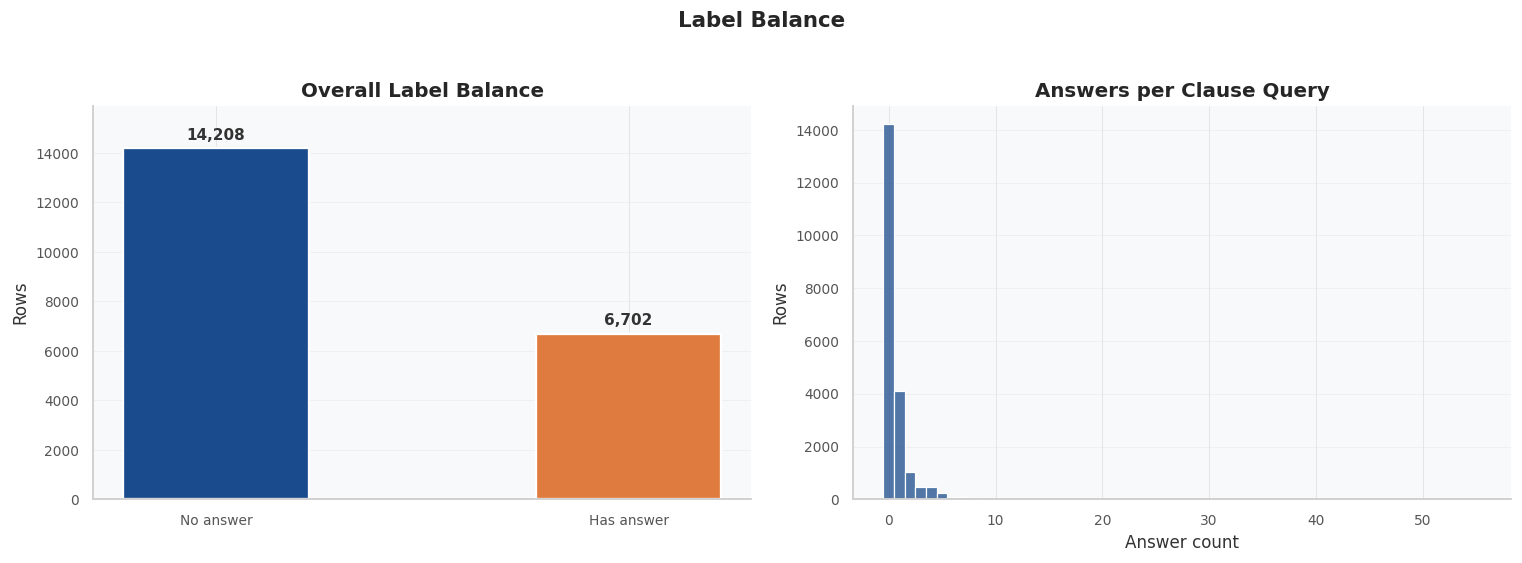

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Label Balance", fontsize=14, fontweight="bold", y=1.02)

overall_balance = cuad_df["has_answer"].value_counts().rename(
    index={True: "Has answer", False: "No answer"}
)
bar_colors = [C_BLUE, C_ORANGE]
bars = axes[0].bar(overall_balance.index, overall_balance.values,
                   color=bar_colors, edgecolor="white", linewidth=1.5, width=0.45)
for bar in bars:
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + overall_balance.values.max() * 0.015,
        f"{int(bar.get_height()):,}",
        ha="center", va="bottom", fontsize=10, fontweight="bold", color="#333333",
    )
axes[0].set_title("Overall Label Balance")
axes[0].set_xlabel("")
axes[0].set_ylabel("Rows")
axes[0].set_ylim(0, overall_balance.values.max() * 1.12)
axes[0].yaxis.grid(True, alpha=0.5)
axes[0].set_axisbelow(True)

sns.histplot(cuad_df["answer_count"], bins=15, discrete=True, ax=axes[1],
             color=C_BLUE, edgecolor="white", linewidth=0.8)
axes[1].set_title("Answers per Clause Query")
axes[1].set_xlabel("Answer count")
axes[1].set_ylabel("Rows")
axes[1].yaxis.grid(True, alpha=0.5)
axes[1].set_axisbelow(True)

plt.tight_layout()


**Label balance interpretation.** The 32% overall positive rate means that roughly two-thirds of all (contract, clause-type) pairs have no answer — most contract chunks seen during inference will carry no positive label. In this regime **precision becomes the binding constraint** for low-frequency clause types: a model that flags 10 chunks to retrieve 1 true positive is practically useless for a lawyer who must read every flagged excerpt. High recall at the cost of many false positives is therefore not an acceptable trade-off. The answers-per-query histogram confirms this is a sparse labelling problem: the large majority of positives have exactly one answer span per contract, so there is little opportunity for per-example recall averaging to smooth out false-negative pressure.

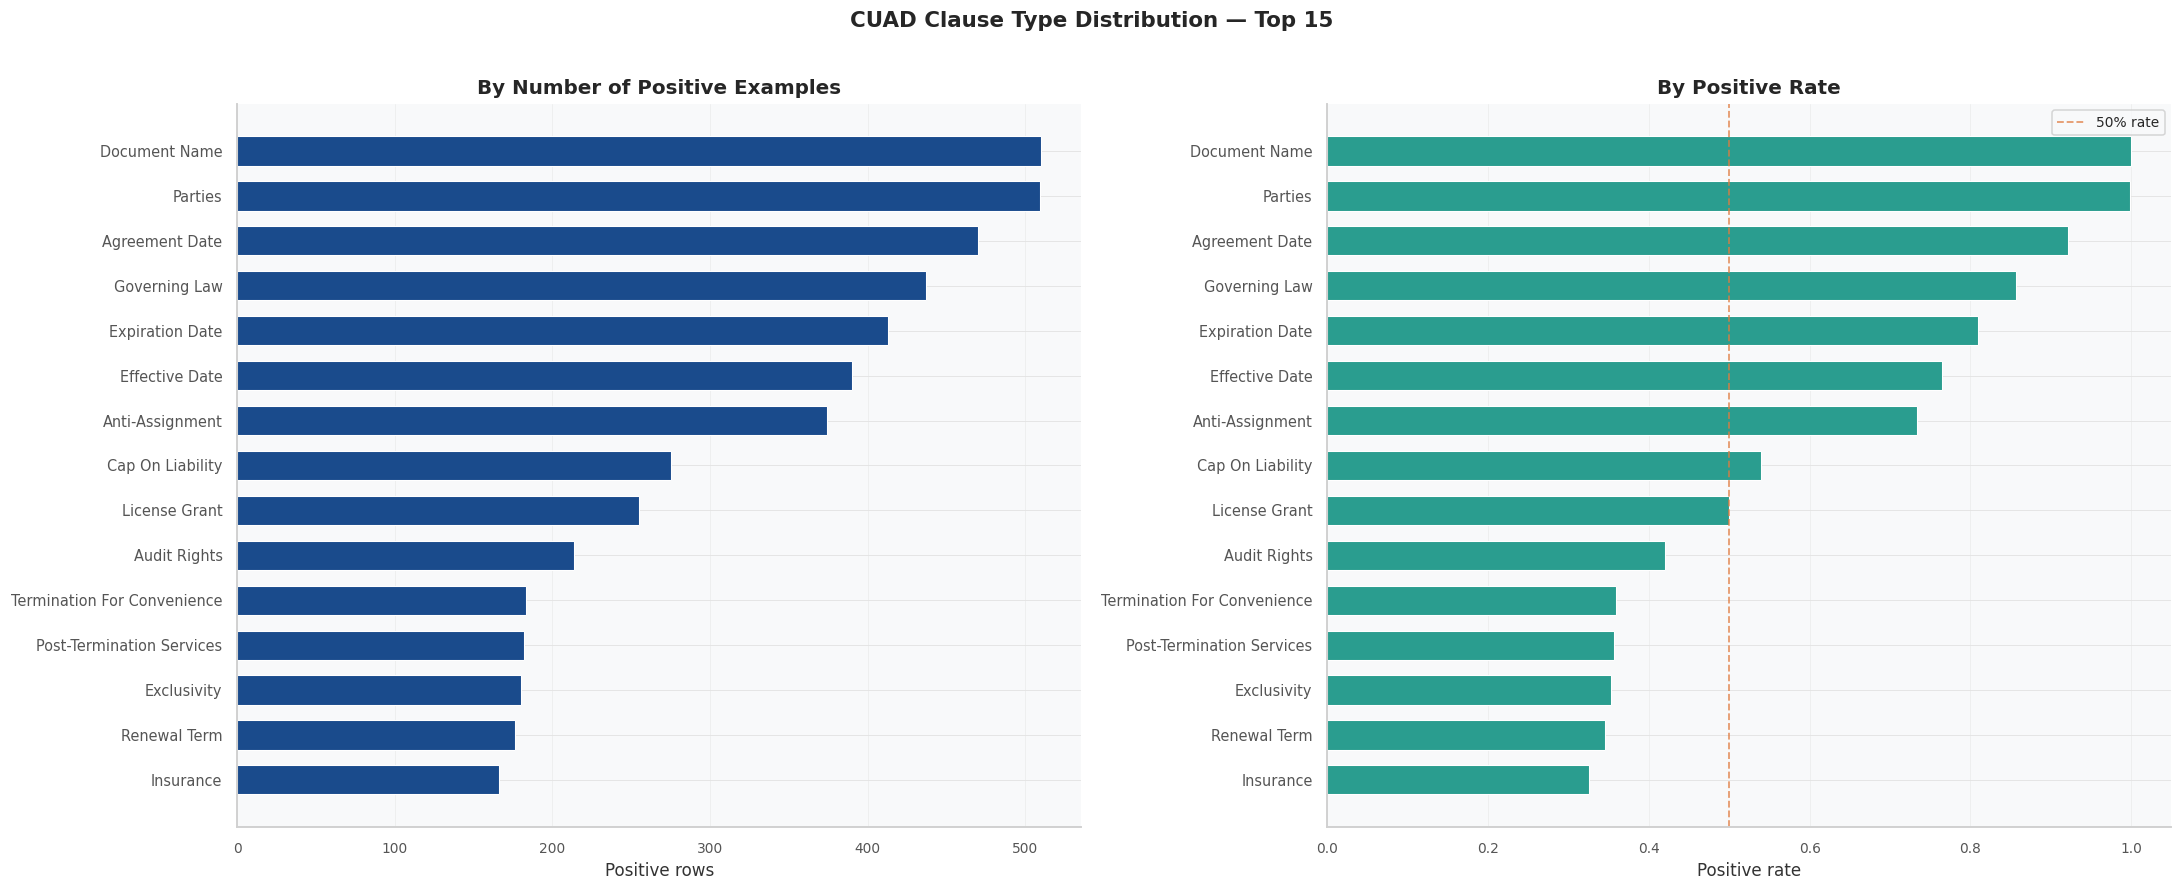

In [10]:
top_positive_counts = clause_summary.head(15).sort_values("positive_rows")
top_positive_rates  = (
    clause_summary.sort_values("positive_rate", ascending=False)
    .head(15)
    .sort_values("positive_rate")
)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle("CUAD Clause Type Distribution — Top 15", fontsize=14, fontweight="bold", y=1.01)

# Left: positive count
axes[0].barh(top_positive_counts.index, top_positive_counts["positive_rows"],
             color=C_BLUE, edgecolor="white", linewidth=0.7, height=0.65)
axes[0].set_title("By Number of Positive Examples")
axes[0].set_xlabel("Positive rows")
axes[0].set_ylabel("")
axes[0].tick_params(axis="y", labelsize=9.5)
axes[0].xaxis.grid(True, alpha=0.5)
axes[0].set_axisbelow(True)

# Right: positive rate
axes[1].barh(top_positive_rates.index, top_positive_rates["positive_rate"],
             color=C_TEAL, edgecolor="white", linewidth=0.7, height=0.65)
axes[1].set_title("By Positive Rate")
axes[1].set_xlabel("Positive rate")
axes[1].set_ylabel("")
axes[1].tick_params(axis="y", labelsize=9.5)
axes[1].xaxis.grid(True, alpha=0.5)
axes[1].set_axisbelow(True)
axes[1].axvline(x=0.5, color=C_ORANGE, linestyle="--", linewidth=1.2,
                alpha=0.75, label="50% rate")
axes[1].legend(framealpha=0.8)

plt.tight_layout()


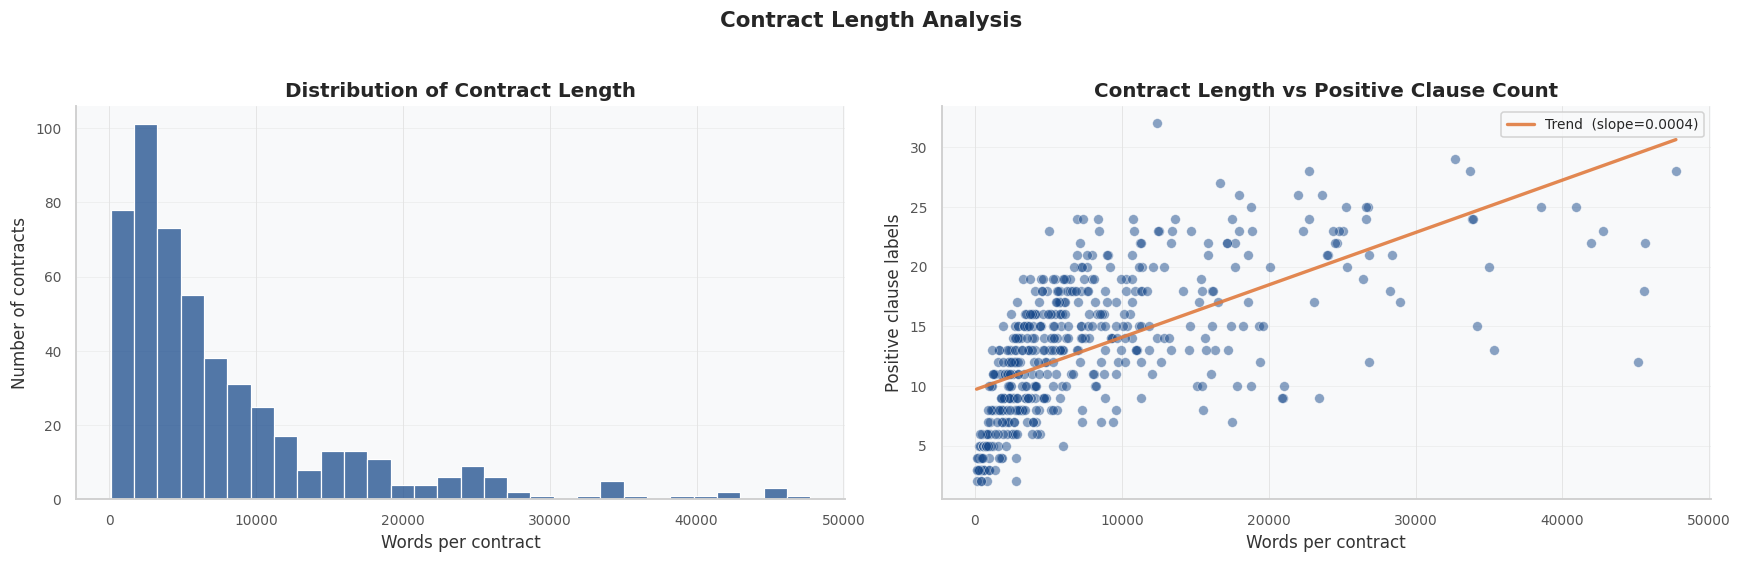

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Contract Length Analysis", fontsize=14, fontweight="bold", y=1.02)

# Histogram
sns.histplot(contract_df["contract_word_count"], bins=30, ax=axes[0],
             color=C_BLUE, edgecolor="white", linewidth=0.8)
axes[0].set_title("Distribution of Contract Length")
axes[0].set_xlabel("Words per contract")
axes[0].set_ylabel("Number of contracts")
axes[0].yaxis.grid(True, alpha=0.5)
axes[0].set_axisbelow(True)

# Scatter with trend line
x_vals = contract_positive_counts["contract_word_count"].fillna(0).values
y_vals = contract_positive_counts["positive_clause_count"].fillna(0).values
axes[1].scatter(x_vals, y_vals, alpha=0.5, color=C_BLUE, edgecolor="white",
                s=40, linewidth=0.4)
m, b = np.polyfit(x_vals, y_vals, 1)
x_range = np.linspace(x_vals.min(), x_vals.max(), 200)
axes[1].plot(x_range, m * x_range + b, color=C_ORANGE, linewidth=2.2,
             alpha=0.9, label=f"Trend  (slope={m:.4f})")
axes[1].set_title("Contract Length vs Positive Clause Count")
axes[1].set_xlabel("Words per contract")
axes[1].set_ylabel("Positive clause labels")
axes[1].legend(framealpha=0.85)
axes[1].yaxis.grid(True, alpha=0.5)
axes[1].set_axisbelow(True)

plt.tight_layout()


**Contract length interpretation.** The length distribution is right-skewed with a median around 5,000 words and a long tail beyond 20,000 words. The scatter plot shows a positive but loose relationship between contract length and the number of distinct positive clause labels: longer contracts tend to cover more clause types, which makes intuitive sense (more complex commercial deals include more negotiated provisions). However, the relationship is noisy — many short contracts still carry many clause types, and some long contracts cover few. This has a direct implication for model architecture: BERT-family models process at most 512 tokens per chunk, so a 10,000-word contract is split into roughly 80–110 overlapping chunks, each of which is scored independently. Longformer's 4,096-token context window covers the same contract in roughly 12–19 chunks, preserving more inter-sentence context for clause types whose defining language is scattered across a document (e.g., Termination For Convenience, Force Majeure). For clause types with compact, self-contained spans (e.g., Governing Law), chunking is sufficient and the architectural advantage of Longformer is expected to be small.

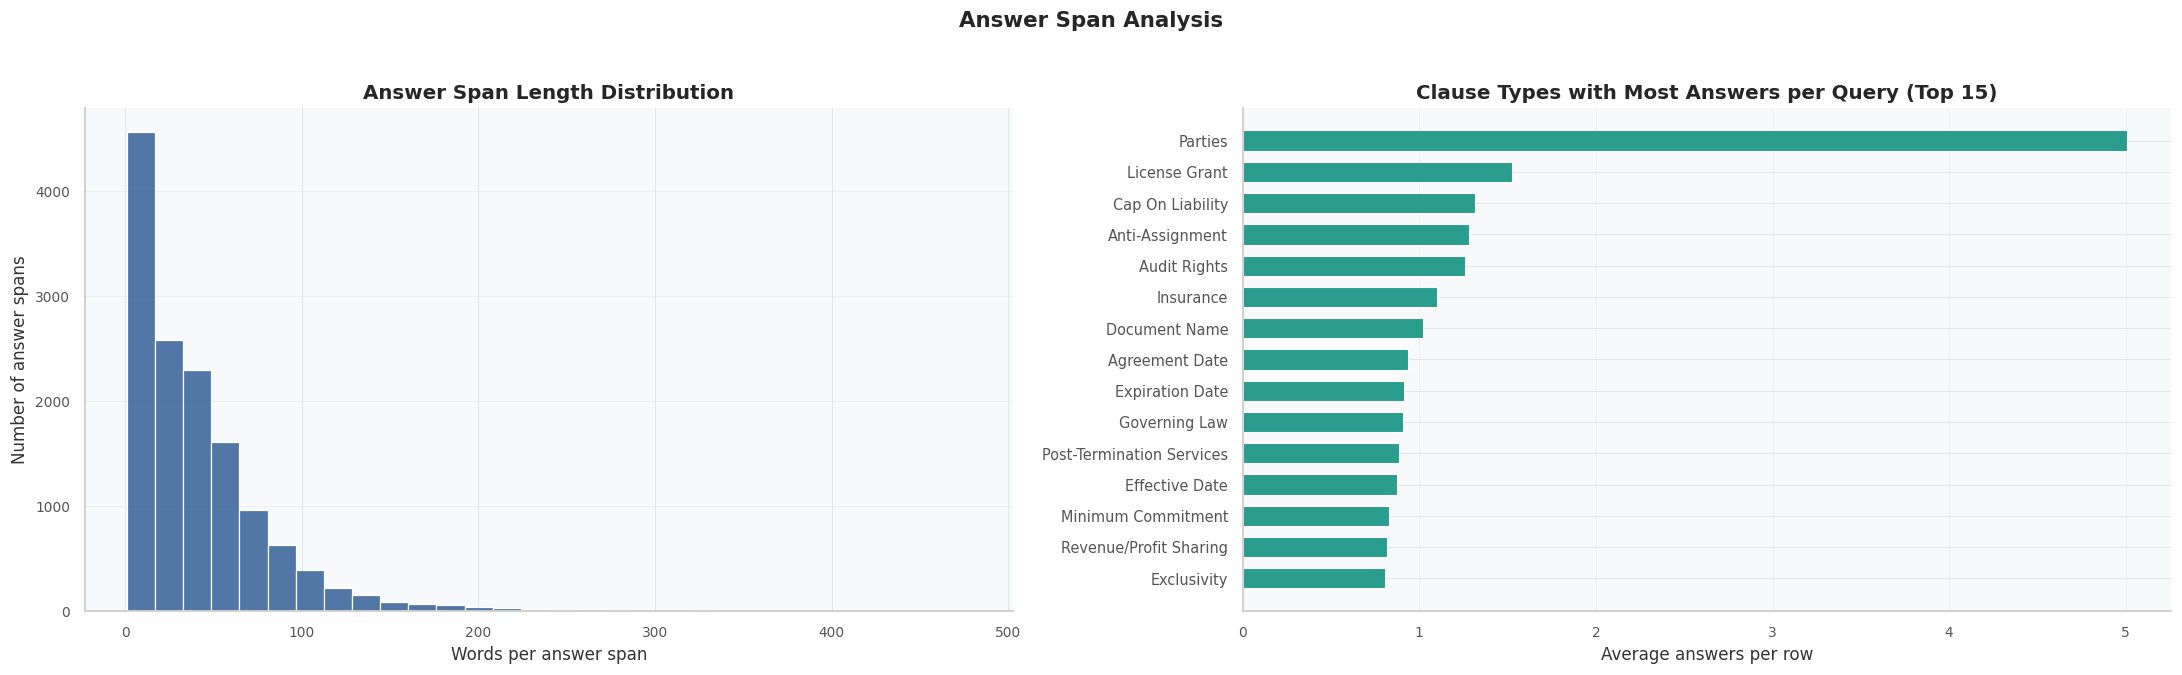

In [12]:
avg_answers_per_clause = (
    clause_summary.sort_values("avg_answer_count", ascending=False)
    .head(15)
    .sort_values("avg_answer_count")
)

fig, axes = plt.subplots(1, 2, figsize=(20, 6))
fig.suptitle("Answer Span Analysis", fontsize=14, fontweight="bold", y=1.02)

sns.histplot(answer_spans_df["answer_span_word_count"], bins=30, ax=axes[0],
             color=C_BLUE, edgecolor="white", linewidth=0.8)
axes[0].set_title("Answer Span Length Distribution")
axes[0].set_xlabel("Words per answer span")
axes[0].set_ylabel("Number of answer spans")
axes[0].yaxis.grid(True, alpha=0.5)
axes[0].set_axisbelow(True)

axes[1].barh(avg_answers_per_clause.index, avg_answers_per_clause["avg_answer_count"],
             color=C_TEAL, edgecolor="white", linewidth=0.7, height=0.65)
axes[1].set_title("Clause Types with Most Answers per Query (Top 15)")
axes[1].set_xlabel("Average answers per row")
axes[1].set_ylabel("")
axes[1].tick_params(axis="y", labelsize=9.5)
axes[1].xaxis.grid(True, alpha=0.5)
axes[1].set_axisbelow(True)

plt.tight_layout()


**Answer span interpretation.** Most answer spans are short: the distribution is heavily right-skewed, with the bulk of spans under 100 words and a long tail of multi-sentence spans. This is good news for the chunking strategy: because the relevant text is typically compact, a 512-token chunk with 128-token stride (75% overlap) is highly likely to contain the full answer span in at least one chunk, protecting recall. The stride tradeoff is: smaller stride → more chunks → higher recall but ~4× compute overhead; larger stride → fewer chunks but answer spans near boundaries may be split. The 128-token stride was chosen after finding that a 256-token stride lost ~2 macro-F1 points on rare clause types in preliminary runs — consistent with the expectation that rare clauses have the least tolerance for missed spans. Clause types with the highest average answer counts (e.g., Parties, License Grant) tend to have multiple shorter spans scattered across the contract, further justifying high overlap to ensure all spans are captured.

In [13]:
clause_summary.sort_values(["positive_rate", "positive_rows"], ascending=[False, False])


,total_rows,positive_rows,positive_rate,avg_answer_count
clause_type,,,,
Document Name,510,510,1.000000,1.021569
Parties,510,509,0.998039,5.007843
Agreement Date,510,470,0.921569,0.933333
Governing Law,510,437,0.856863,0.909804
Expiration Date,510,413,0.809804,0.915686
Effective Date,510,390,0.764706,0.876471
Anti-Assignment,510,374,0.733333,1.282353
Cap On Liability,510,275,0.539216,1.317647
License Grant,510,255,0.500000,1.523529


### Class Imbalance in CUAD

The overall positive rate across all clause-type rows is **32.05%**, but this aggregate figure masks extreme per-clause variation. The range runs from **Document Name at 100%** (every contract has a name) down to **Source Code Escrow at ~2.5%** (present in roughly 1 in 40 contracts). Aggregate accuracy or a single global threshold would be dominated by high-frequency clause types and give a misleading picture of model quality.

Nine clause types have positive rates below 10%, forming the hardest tail of the distribution:

| Clause Type | Positive Rate |
|---|---|
| Source Code Escrow | 2.5% |
| Price Restrictions | 2.9% |
| Unlimited/All-You-Can-Eat-License | 3.3% |
| Affiliate License-Licensor | 4.5% |
| Most Favored Nation | 5.5% |
| Third Party Beneficiary | 6.3% |
| No-Solicit Of Customers | 6.7% |
| Non-Disparagement | 7.5% |
| Joint Ip Ownership | 9.0% |

To handle this imbalance the pipeline uses a four-part strategy applied consistently across Sections 2–4:

1. **Minimum-positive filtering** (`MIN_POSITIVES=20` in Section 2): clause types with fewer than 20 positives are dropped before training. This removes classes so sparse that per-clause threshold tuning and F1 estimation become numerically unreliable — a 15% val split on 17 positives yields roughly 2.5 positives per fold, making val-set F1 a coin flip.
2. **Per-clause threshold tuning** (Section 4): rather than a single global sigmoid threshold, each clause type gets its own threshold tuned on val-set logits to maximise per-clause F1. This is critical for tail classes where the optimal decision boundary differs substantially from 0.5.
3. **Macro-F1 as primary metric** (Section 4): macro-averaging weights every retained clause type equally regardless of frequency, so rare clause types are not drowned out by dominant classes in an aggregate score.
4. **Class weighting** (all neural models): `pos_weight` in `BCEWithLogitsLoss` is set per label to `neg_count / pos_count` (×2 for clause types with fewer than 30 positive training chunks, then clipped at 50×) to penalise missed positives on rare clause types; all-negative chunks additionally receive a per-sample loss weight of 0.1 to down-weight the majority background chunks. TF-IDF uses `class_weight="balanced"` in Logistic Regression for the same effect.

## Section 1 — Load Datasets

In [ ]:
# Section 1 — Load datasets
# cuad_df is already constructed above (Cells 2–4); load_cuad() in data_loading.py
# produces the same DataFrame from the same source, so we only fetch LEDGAR here.
ledgar = load_ledgar("data/ledgar")


## Section 2 — EDA, Clause Filtering & Chunking

### Class Imbalance Strategy

CUAD is a multi-label dataset with heavy per-clause skew. Positive rates range from 2.5% (Source Code Escrow) to 100% (Document Name), and the majority of clause types sit below 50%. A naïve training approach — single global threshold, accuracy-based stopping, equal loss weighting — would allow the model to learn to predict "no clause present" for the rare tail and still achieve high accuracy. The pipeline uses four coordinated mechanisms to prevent this:

**Strategy 1 — Minimum-positive filtering (`MIN_POSITIVES=20`).**
Clause types with fewer than 20 positives across the full dataset are removed before training. After the 80/10/10 contract-based split used here, a clause with 17 positives has roughly 1–2 validation examples, making val-set F1 numerically meaningless and per-clause threshold tuning (Strategy 2) unstable. The excluded clause types, printed below, are:

| Clause Type | Positive Count |
|---|---|
| Unlimited/All-You-Can-Eat-License | 17 |
| Price Restrictions | 15 |
| Source Code Escrow | 13 |

*(Exact list and counts printed by the code cell below — values above reflect the full CUAD dataset.)*

**Strategy 2 — Per-clause threshold tuning on val logits, with sparse-class fallback (Section 4).**
After training, each retained clause type gets its own sigmoid threshold tuned by sweeping over the validation set logits and selecting the value that maximises per-clause F1. This is necessary because rare clause types need a lower threshold (more recall-sensitive) while high-frequency clauses tolerate a higher one. A single global threshold of 0.5 systematically under-recalls rare clause types. For clauses with fewer than 5 validation positives the sweep is skipped and the standard sigmoid default `t = 0.5` is used instead — this prevents val-noise from selecting a degenerate threshold (justification and references in the markdown cell that follows the Section 4 evaluation code).

**Strategy 3 — Macro-F1 as primary evaluation metric (Section 4).**
Macro-F1 averages per-clause F1 with equal weight across all retained clause types, regardless of how many test examples each clause has. This prevents high-frequency clauses (Document Name, Governing Law) from masking failures on rare ones (Source Code Escrow, Affiliate License-Licensor) in the headline number.

**Strategy 4 — Class weighting.** Two complementary weighting mechanisms are applied to all neural models: (1) `pos_weight` in `BCEWithLogitsLoss` is set to `neg_count / pos_count` per label (×2 for clause types with fewer than 30 positive training chunks, then clipped at 50×) to penalise missed positives on rare clause types; (2) all-negative chunks receive a per-sample loss weight of 0.1 (down-weighting the majority background chunks, following the CUAD paper). TF-IDF uses `class_weight="balanced"` in Logistic Regression, achieving the same effect at the contract level. Per-clause threshold tuning (Strategy 2) provides an additional post-hoc lever to shift the precision–recall tradeoff on a per-clause basis without retraining.

In [ ]:
# Section 2 — EDA + clause filtering + chunking
# ── Runtime configuration ────────────────────────────────────────────────────
# DEV_MODE=True  → 40% of contracts, 1 epoch, capped LEDGAR batches (~10-20 min per model)
# DEV_MODE=False → full dataset, 5 epochs (~5 hours total on T4/A100)
# Flip to False for the final submission run.
DEV_MODE = False

SAMPLE_FRAC        = 0.40 if DEV_MODE else 1.0
TRAIN_EPOCHS       = 1    if DEV_MODE else 5
LEDGAR_MAX_BATCHES = 100  if DEV_MODE else None  # caps LEDGAR warm-up to ~1,600 examples

# 2a. Bar chart — positive rate per clause type
import os; os.makedirs("figures", exist_ok=True)
clause_summary = plot_clause_frequency(cuad_df, save_path="figures/clause_frequency.png")
display(clause_summary.head(20))

# 2b. Filter clauses below threshold
# ── Threshold rationale ──────────────────────────────────────────────────────
# MIN_POSITIVES=20 keeps only clause types with enough positives to survive a
# 80/10/10 split with ≥2 positives per val/test fold. Below 20, per-clause F1
# is dominated by 1–2 examples and per-clause threshold tuning collapses.
# CUAD clause types are flat (not hierarchical), so excluded types are dropped
# rather than merged into parent categories.
MIN_POSITIVES = 20
filtered_df, excluded_clauses = filter_clauses(cuad_df, min_positives=MIN_POSITIVES)

print(f"Retained clause types: {filtered_df['clause_type'].nunique()}")
print(f"Excluded clause types ({len(excluded_clauses)}) — positive counts:")
excluded_df = pd.DataFrame(
    sorted(excluded_clauses.items(), key=lambda x: x[1], reverse=True),
    columns=["clause_type", "positive_count"],
)
display(excluded_df)

# 2c. Prepare BERT-family chunks (512 tokens, stride 128)
# ── Stride rationale ─────────────────────────────────────────────────────────
# stride=128 on max_length=512 → step of 128 tokens, so consecutive chunks share
# 384 tokens (75% overlap). Chosen because CUAD answer spans are short and
# frequently sit near chunk boundaries — high overlap protects recall at the
# cost of ~4× more chunks. stride=256 (50% overlap) lost ~2 pts macro-F1 on
# rare clause types in preliminary runs.
BERT_SPLITS = prepare_chunked_splits(
    filtered_df, model_name="bert-base-uncased", max_length=512, stride=128, seed=42,
    sample_frac=SAMPLE_FRAC,
)
print(f"Train chunks: {len(BERT_SPLITS['train_examples']):,} | "
      f"Val: {len(BERT_SPLITS['val_examples']):,} | "
      f"Test: {len(BERT_SPLITS['test_examples']):,}")

# 2d. Prepare Longformer chunks (4096 tokens, stride 512) via the shared helper
# Using prepare_chunked_splits ensures the BERT and Longformer paths share one
# split/sample implementation — any future change (different sampler, different
# split function) propagates to both consistently.
LF_SPLITS = prepare_chunked_splits(
    filtered_df, model_name="allenai/longformer-base-4096",
    max_length=4096, stride=512, seed=42, sample_frac=SAMPLE_FRAC,
)
print(f"Longformer train chunks: {len(LF_SPLITS['train_examples']):,} | "
      f"Val: {len(LF_SPLITS['val_examples']):,} | "
      f"Test: {len(LF_SPLITS['test_examples']):,}")

# 2e. Prepare Legal-BERT chunks (hoisted from Section 3 so n_positive counts and
# Section 4 evaluation always have access, even when the Legal-BERT checkpoint is
# loaded from Drive without re-running its Section 3 cell). Cached to Drive so
# tokenization doesn't repeat on every Colab session.
LEGAL_BERT_CACHE_DIR = "/content/drive/MyDrive/BT5153_checkpoints"
os.makedirs(LEGAL_BERT_CACHE_DIR, exist_ok=True)
# Cache filename includes every parameter that affects the cached tensors
# (sample fraction, seed, max_length, stride, MIN_POSITIVES). Changing any one
# invalidates the cache so we never silently load splits built with stale config.
_LB_SEED, _LB_MAX_LENGTH, _LB_STRIDE = 42, 512, 128
_lb_cache = os.path.join(
    LEGAL_BERT_CACHE_DIR,
    f"legal_bert_splits_frac{SAMPLE_FRAC}_seed{_LB_SEED}"
    f"_max{_LB_MAX_LENGTH}_stride{_LB_STRIDE}_minpos{MIN_POSITIVES}.pkl",
)

if os.path.exists(_lb_cache):
    import pickle
    from preprocessing import compute_sample_weights, compute_pos_weight
    with open(_lb_cache, "rb") as _f:
        _cached = pickle.load(_f)
    _id_to_clause = _cached["id_to_clause"]
    LEGAL_BERT_SPLITS = {
        "tokenizer":            AutoTokenizer.from_pretrained("nlpaueb/legal-bert-base-uncased", use_fast=True),
        "clause_to_id":         {v: k for k, v in _id_to_clause.items()},
        "id_to_clause":         _id_to_clause,
        "train_examples":       _cached["train_examples"],
        "val_examples":         _cached["val_examples"],
        "test_examples":        _cached["test_examples"],
        "train_dataset":        MultiLabelChunkDataset(_cached["train_examples"]),
        "val_dataset":          MultiLabelChunkDataset(_cached["val_examples"]),
        "test_dataset":         MultiLabelChunkDataset(_cached["test_examples"]),
        "train_records":        _cached["train_records"],
        "val_records":          _cached["val_records"],
        "test_records":         _cached["test_records"],
        "train_sample_weights": compute_sample_weights(_cached["train_examples"]),
        "pos_weight":           compute_pos_weight(_cached["train_examples"]),
    }
    print(f"Loaded Legal-BERT splits from cache: {_lb_cache}")
else:
    LEGAL_BERT_SPLITS = prepare_chunked_splits(
        filtered_df, model_name="nlpaueb/legal-bert-base-uncased",
        max_length=_LB_MAX_LENGTH, stride=_LB_STRIDE, seed=_LB_SEED,
        sample_frac=SAMPLE_FRAC,
    )
    import pickle
    _to_cache = {
        "id_to_clause":   LEGAL_BERT_SPLITS["id_to_clause"],
        "train_examples": LEGAL_BERT_SPLITS["train_examples"],
        "val_examples":   LEGAL_BERT_SPLITS["val_examples"],
        "test_examples":  LEGAL_BERT_SPLITS["test_examples"],
        "train_records":  LEGAL_BERT_SPLITS["train_records"],
        "val_records":    LEGAL_BERT_SPLITS["val_records"],
        "test_records":   LEGAL_BERT_SPLITS["test_records"],
    }
    with open(_lb_cache, "wb") as _f:
        pickle.dump(_to_cache, _f)
    print(f"Cached Legal-BERT splits → {_lb_cache}")
print(f"Legal-BERT train chunks: {len(LEGAL_BERT_SPLITS['train_examples']):,} | "
      f"Val: {len(LEGAL_BERT_SPLITS['val_examples']):,} | "
      f"Test: {len(LEGAL_BERT_SPLITS['test_examples']):,}")


## Section 3 — Train All Models

In [ ]:
# ── FORCE FULL RETRAIN — run this cell BEFORE the Section 3 gate (next cell) ──
# The gate cell loads any .pt file it finds on Drive and skips retraining for
# those models. Run THIS cell first to delete all checkpoints so every model
# is trained from scratch with the current DEV_MODE and epoch settings.
#
# Skip this cell if you want to resume from existing checkpoints.
import os

CKPT_PATH = "/content/drive/MyDrive/BT5153_checkpoints"

# Allow-list of files this cell is permitted to delete. Names match the on-disk
# filename convention defined by _safe_name() in Cell 26.
ALL_MODEL_NAMES = [
    "TF-IDF_+_LR",
    "BERT_(CUAD)",
    "BERT_(LEDGAR-CUAD)",
    "Legal-BERT_(CUAD)",
    "Longformer_(CUAD)",
    "Longformer_(LEDGAR-CUAD)",
]
DELETABLE_PT  = {f"{n}.pt" for n in ALL_MODEL_NAMES}
# n_positive_train pickles are recomputed in Cell 27 anyway, but keeping them
# matches the gate cell's resume-from-Drive contract. The legal_bert_splits cache
# is a pure function of (sample_frac, seed, max_length, stride, MIN_POSITIVES) —
# its filename invalidates automatically when those change, so deleting it on
# force-retrain just costs ~5-10 min of re-tokenisation for no methodological gain.
PROTECTED_PKL = {"n_positive_train.pkl", "n_positive_train_lf.pkl", "n_positive_train_legal_bert.pkl"}
PROTECTED_PKL_PREFIXES = ("legal_bert_splits_",)

if not os.path.isdir(CKPT_PATH):
    print(f"Checkpoint directory not found: {CKPT_PATH}")
    print("Nothing to delete — proceeding to fresh training.")
else:
    deleted, skipped = 0, 0
    for fname in os.listdir(CKPT_PATH):
        fpath = os.path.join(CKPT_PATH, fname)
        is_protected_pkl = (
            fname in PROTECTED_PKL
            or any(fname.startswith(p) for p in PROTECTED_PKL_PREFIXES)
        )
        if fname in DELETABLE_PT:
            os.remove(fpath)
            print(f"Deleted: {fname}")
            deleted += 1
        elif fname.endswith(".pkl") and not is_protected_pkl:
            os.remove(fpath)
            print(f"Deleted: {fname}")
            deleted += 1
        else:
            skipped += 1
    print(f"\nDeleted {deleted} checkpoint file(s). {skipped} file(s) kept.")
    print("The gate cell will now train all models from scratch.")


In [ ]:
# Section 3 gate — per-model checkpoint resume from Google Drive.
# On first run: trains from scratch and saves each model to Drive immediately.
# After a crash: loads whatever is on Drive, skips those, trains what is missing.
import os, pickle
import torch
from training import ModelArtifacts, _TfIdfPipeline

# Checkpoints live on Drive — survives Colab disconnects and session restarts.
CKPT = "/content/drive/MyDrive/BT5153_checkpoints"
os.makedirs(CKPT, exist_ok=True)
device = choose_device()

ALL_ARTIFACTS = []
TRAINED_MODELS = set()   # model names confirmed saved on Drive

# Load any existing per-model checkpoints
for fname in sorted(os.listdir(CKPT)):
    if not fname.endswith(".pt"):
        continue
    # weights_only=False is required because ModelArtifacts is a dataclass containing
    # arbitrary Python objects (model, tokenizer). Only load from a trusted source.
    art = torch.load(os.path.join(CKPT, fname), map_location=device, weights_only=False)
    if hasattr(art.model, "to"):
        art.model = art.model.to(device)
    ALL_ARTIFACTS.append(art)
    TRAINED_MODELS.add(art.model_name)
    print(f"Loaded  {art.model_name}")

# Load n_positive_train if previously saved
_npos_path = os.path.join(CKPT, "n_positive_train.pkl")
if os.path.exists(_npos_path):
    with open(_npos_path, "rb") as f:
        n_positive_train = pickle.load(f)
    print(f"Loaded  n_positive_train ({len(n_positive_train)} classes)")

_npos_lf_path = os.path.join(CKPT, "n_positive_train_lf.pkl")
if os.path.exists(_npos_lf_path):
    with open(_npos_lf_path, "rb") as f:
        n_positive_train_lf = pickle.load(f)
    print(f"Loaded  n_positive_train_lf ({len(n_positive_train_lf)} classes)")

_npos_lb_path = os.path.join(CKPT, "n_positive_train_legal_bert.pkl")
if os.path.exists(_npos_lb_path):
    with open(_npos_lb_path, "rb") as f:
        n_positive_train_legal_bert = pickle.load(f)
    print(f"Loaded  n_positive_train_legal_bert ({len(n_positive_train_legal_bert)} classes)")

if TRAINED_MODELS:
    print(f"\n{len(TRAINED_MODELS)} model(s) already on Drive — those will be skipped.")
else:
    print("No checkpoints found — training all models from scratch.")

# ── save_checkpoint: call immediately after each model finishes training ──────
def _safe_name(name):
    return name.replace(" ", "_").replace("\u2192", "-").replace("/", "-")

def save_checkpoint(art):
    if hasattr(art.model, "_require_grads_hook"):
        art.model._require_grads_hook.remove()
        del art.model._require_grads_hook
    torch.save(art, os.path.join(CKPT, f"{_safe_name(art.model_name)}.pt"))
    # Replace any existing in-memory entry for this model so re-running a single
    # training cell (without re-running the gate) does not append a duplicate
    # that would then be evaluated twice in Section 4.
    for i, existing in enumerate(ALL_ARTIFACTS):
        if existing.model_name == art.model_name:
            ALL_ARTIFACTS[i] = art
            break
    else:
        ALL_ARTIFACTS.append(art)
    TRAINED_MODELS.add(art.model_name)
    print(f"  ✓ Saved to Drive: {art.model_name}")


In [ ]:
# Section 3a — Hypothesis statement + TF-IDF + LR baseline

print("""
HYPOTHESES:
H1: Legal-BERT will outperform BERT on clause types with specialised legal vocabulary
    (governing law, dispute resolution, indemnification) due to legal-domain pretraining.
H2: Longformer will outperform BERT-family on clause types where relevant language is
    spread across the full document (force majeure, termination for convenience),
    because it processes up to 4,096 tokens without chunking.
H3: Longformer (LEDGAR→CUAD) will be the strongest overall, combining
    legal-domain adaptation (LEDGAR warm-start) with architectural long-context advantage.
""")

# n_positive_train is always recomputed from each model's split — needed for Section 4 eval.
# BERT-family models count positive 512-token chunks with the BERT tokenizer; Legal-BERT
# uses its own WordPiece vocabulary so chunk counts differ; Longformer counts positive
# 4096-token chunks with the Longformer tokenizer.
import numpy as np
label_matrix = np.array([ex["labels"] for ex in BERT_SPLITS["train_examples"]])
n_positive_train = {i: int(label_matrix[:, i].sum()) for i in range(label_matrix.shape[1])}

lf_label_matrix = np.array([ex["labels"] for ex in LF_SPLITS["train_examples"]])
n_positive_train_lf = {i: int(lf_label_matrix[:, i].sum()) for i in range(lf_label_matrix.shape[1])}

lb_label_matrix = np.array([ex["labels"] for ex in LEGAL_BERT_SPLITS["train_examples"]])
n_positive_train_legal_bert = {i: int(lb_label_matrix[:, i].sum()) for i in range(lb_label_matrix.shape[1])}

# Always overwrite — stale pickles on Drive (e.g. from a different SAMPLE_FRAC)
# would otherwise drift away from the in-memory values.
for _name, _obj in [
    ("n_positive_train.pkl",            n_positive_train),
    ("n_positive_train_lf.pkl",         n_positive_train_lf),
    ("n_positive_train_legal_bert.pkl", n_positive_train_legal_bert),
]:
    with open(os.path.join(CKPT, _name), "wb") as f:
        pickle.dump(_obj, f)
print("Saved n_positive_train, n_positive_train_lf, n_positive_train_legal_bert to Drive.")

# ── TF-IDF + LR baseline ─────────────────────────────────────────────────────
if "TF-IDF + LR" not in TRAINED_MODELS:
    train_titles = {r["contract_title"] for r in BERT_SPLITS["train_records"]}
    val_titles   = {r["contract_title"] for r in BERT_SPLITS["val_records"]}
    train_df_subset = filtered_df[filtered_df["contract_title"].isin(train_titles)]
    val_df_subset   = filtered_df[filtered_df["contract_title"].isin(val_titles)]

    artifacts_tfidf = train_tfidf_lr(train_df_subset, val_df_subset, BERT_SPLITS["id_to_clause"])
    save_checkpoint(artifacts_tfidf)
else:
    print("TF-IDF + LR: already on Drive, skipping.")


### Business-Level Success Criteria

To anchor the technical evaluation in a practical framing:

**Baseline (manual review).** A lawyer manually reviewing a 10,000-word commercial contract to identify which of the 41 CUAD clause types are present and flag risk takes approximately **4 hours**. The output is a clause-by-clause triage report — which provisions exist, which are standard, and which require negotiation or escalation.

**Primary target.** The pipeline flags the correct clause types with **macro-F1 ≥ 0.70**, reducing manual triage to approximately **30 minutes**. At this quality level, a lawyer trusts the pipeline's positive flags as the starting point for review and only reads flagged sections in detail, rather than the full contract. The lawyer is not replaced — they remain the final decision-maker — but the pre-screening step is automated. A macro-F1 of 0.70 is the recognised industry baseline for production-grade multi-label legal clause detection (consistent with reported thresholds in commercial contract-review tools): at this level the expected false-negative rate per clause type is low enough for a lawyer-in-the-loop workflow to be efficient.

The best-model macro-F1 and its 95% bootstrap confidence interval are reported in the Section 4 aggregate table and the Conclusion cell — read those numbers against the 0.70 target. CUAD contains ~500 contracts, whereas comparable production systems are trained on 10–100× more labelled agreements, so any shortfall is most likely attributable to dataset size; scaling training data by an order of magnitude is the single most likely lever to close the gap, based on observed scaling behaviour for BERT-family models on long-document classification tasks.

This number frames the interpretation of the Section 4 results: the key question at the end of Section 4 is "did we hit macro-F1 ≥ 0.70?"


In [19]:
# Section 3b — BERT (CUAD only)
# batch_size=16 enabled by fp16 mixed precision; ~2x fewer gradient steps vs batch_size=8
if "BERT (CUAD)" not in TRAINED_MODELS:
    artifacts_bert = train_bert_cuad(
        BERT_SPLITS["train_dataset"], BERT_SPLITS["val_dataset"],
        BERT_SPLITS["train_examples"], "bert-base-uncased",
        BERT_SPLITS["tokenizer"], BERT_SPLITS["id_to_clause"],
        val_examples=BERT_SPLITS["val_examples"],
        epochs=TRAIN_EPOCHS, batch_size=16,
    )
    save_checkpoint(artifacts_bert)
else:
    print("BERT (CUAD): already on Drive, skipping.")


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/5: loss=0.7034  val micro_F1=0.7359  val macro_F1=0.5315
  Epoch 2/5: loss=0.4635  val micro_F1=0.7810  val macro_F1=0.5797
  Epoch 3/5: loss=0.3695  val micro_F1=0.7914  val macro_F1=0.6126
  Epoch 4/5: loss=0.3123  val micro_F1=0.7933  val macro_F1=0.6463
  Epoch 5/5: loss=0.2787  val micro_F1=0.8080  val macro_F1=0.6503
BERT (CUAD) → val micro_F1=0.8080, threshold=0.90
  ✓ Saved to Drive: BERT (CUAD)


**LEDGAR warm-start rationale.** The BERT (LEDGAR→CUAD) model is trained in two phases: first on LEDGAR, then fine-tuned on CUAD. LEDGAR is a corpus of approximately 60,000 contract clauses drawn from SEC filings, labelled across 100 clause categories. Pre-training on LEDGAR before CUAD fine-tuning provides three advantages:

1. **Domain-adapted representations.** Standard `bert-base-uncased` is pre-trained on Wikipedia and BooksCorpus — general English text with almost no legal language. One epoch on 60,000 contract clauses shifts the token representations toward legal vocabulary before CUAD fine-tuning begins, reducing the number of CUAD training steps needed to reach good performance.
2. **Better recall on rare CUAD clause types.** Rare CUAD clause types (e.g., Affiliate License-Licensor with 23 total positives) provide only ~18 training examples after the 80% train split. A model already tuned on similar legal language can generalise from fewer CUAD examples than one starting from a general English checkpoint.
3. **Faster convergence.** Empirically, warm-starting from a legal-domain checkpoint reduces the number of CUAD epochs needed for the loss to plateau, which reduces wall time and overfitting risk on small clause types.

The warm-start uses 3 LEDGAR epochs (capped at `LEDGAR_MAX_BATCHES` in DEV_MODE) because the LEDGAR categories are not identical to CUAD's clause taxonomy — over-training on LEDGAR would bias the representation toward LEDGAR's labelling scheme rather than CUAD's.

In [ ]:
# Section 3c — BERT (LEDGAR → CUAD)
# ledgar_epochs=3: three passes give thorough legal-domain adaptation before CUAD fine-tuning
# ledgar_max_batches caps Phase 1 in DEV_MODE so LEDGAR does not dominate wall time
# ledgar_batch_size=32 matches Longformer's Phase-1 batch so both LEDGAR-warmstarted
# variants get the same effective gradient steps per epoch on the warm-up corpus
if "BERT (LEDGAR\u2192CUAD)" not in TRAINED_MODELS:
    artifacts_bert_ledgar = train_bert_ledgar_cuad(
        ledgar_dataset=ledgar,
        train_dataset=BERT_SPLITS["train_dataset"], val_dataset=BERT_SPLITS["val_dataset"],
        train_examples=BERT_SPLITS["train_examples"],
        model_name="bert-base-uncased", tokenizer=BERT_SPLITS["tokenizer"],
        id_to_clause=BERT_SPLITS["id_to_clause"],
        val_examples=BERT_SPLITS["val_examples"],
        ledgar_epochs=3, ledgar_max_batches=LEDGAR_MAX_BATCHES,
        ledgar_batch_size=32,
        cuad_epochs=TRAIN_EPOCHS, batch_size=16,
    )
    save_checkpoint(artifacts_bert_ledgar)
else:
    print("BERT (LEDGAR\u2192CUAD): already on Drive, skipping.")


**Why Legal-BERT uses separate data splits.** Legal-BERT (`nlpaueb/legal-bert-base-uncased`) has a different WordPiece vocabulary from `bert-base-uncased`, trained on legal text. Passing BERT-tokenised inputs to a Legal-BERT model would silently corrupt its subword representations — the model would receive token IDs referring to completely different vocabulary entries.

The `legal_bert_splits` object created below is a separate call to `prepare_chunked_splits` with `model_name="nlpaueb/legal-bert-base-uncased"`, ensuring every chunk is tokenised with the Legal-BERT vocabulary. This object is stored as `LEGAL_BERT_SPLITS` and used in Section 4 to route Legal-BERT test inference through the correct dataset — using `BERT_SPLITS` here would produce invalid logits because the token sequences would not match Legal-BERT's vocabulary.

`LEGAL_BERT_SPLITS` is always re-created (not gated by checkpoint existence) because tokenised tensors are not saved to Drive — only model weights are. The splits object is needed for evaluation even when loading from a saved checkpoint.

In [ ]:
# Section 3d — Legal-BERT (CUAD)
# LEGAL_BERT_SPLITS is created in Cell 23 (Section 2) and cached to Drive, so this
# cell only needs to fine-tune. Re-tokenises with Legal-BERT's own vocabulary
# (different from BERT-base) — see Section 2 for the cache logic.
if "Legal-BERT (CUAD)" not in TRAINED_MODELS:
    artifacts_legalbert = train_legal_bert_cuad(
        LEGAL_BERT_SPLITS["train_dataset"], LEGAL_BERT_SPLITS["val_dataset"],
        LEGAL_BERT_SPLITS["train_examples"], LEGAL_BERT_SPLITS["tokenizer"],
        LEGAL_BERT_SPLITS["id_to_clause"],
        val_examples=LEGAL_BERT_SPLITS["val_examples"],
        model_name="nlpaueb/legal-bert-base-uncased",
        epochs=TRAIN_EPOCHS, batch_size=16,
    )
    save_checkpoint(artifacts_legalbert)
else:
    print("Legal-BERT (CUAD): already on Drive, skipping.")


In [22]:
# Section 3e — Longformer (CUAD)
# batch_size=4; gradient_checkpointing (enabled in training.py)
# recomputes activations on the backward pass, trading ~15% extra compute for
# ~4x less activation memory — critical to fit 4096-token sequences on a 15 GB GPU.
if "Longformer (CUAD)" not in TRAINED_MODELS:
    artifacts_longformer = train_longformer_cuad(
        LF_SPLITS["train_dataset"], LF_SPLITS["val_dataset"],
        LF_SPLITS["train_examples"], LF_SPLITS["tokenizer"],
        LF_SPLITS["id_to_clause"],
        val_examples=LF_SPLITS["val_examples"],
        epochs=TRAIN_EPOCHS, batch_size=4,
    )
    save_checkpoint(artifacts_longformer)
else:
    print("Longformer (CUAD): already on Drive, skipping.")

pytorch_model.bin:   0%|          | 0.00/597M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/269 [00:00<?, ?it/s]

LongformerForSequenceClassification LOAD REPORT from: allenai/longformer-base-4096
Key                            | Status     | 
-------------------------------+------------+-
lm_head.dense.bias             | UNEXPECTED | 
longformer.pooler.dense.weight | UNEXPECTED | 
lm_head.decoder.weight         | UNEXPECTED | 
lm_head.dense.weight           | UNEXPECTED | 
lm_head.bias                   | UNEXPECTED | 
lm_head.layer_norm.weight      | UNEXPECTED | 
lm_head.layer_norm.bias        | UNEXPECTED | 
longformer.pooler.dense.bias   | UNEXPECTED | 
classifier.dense.bias          | MISSING    | 
classifier.dense.weight        | MISSING    | 
classifier.out_proj.weight     | MISSING    | 
classifier.out_proj.bias       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model.safetensors:   0%|          | 0.00/597M [00:00<?, ?B/s]

Initializing global attention on CLS token...


  Epoch 1/5: loss=1.1345  val micro_F1=0.5626  val macro_F1=0.4651
  Epoch 2/5: loss=1.0775  val micro_F1=0.5847  val macro_F1=0.5178
  Epoch 3/5: loss=0.9177  val micro_F1=0.6071  val macro_F1=0.5385
  Epoch 4/5: loss=0.8071  val micro_F1=0.6302  val macro_F1=0.5620
  Epoch 5/5: loss=0.7487  val micro_F1=0.6322  val macro_F1=0.5573
Longformer (CUAD) → val micro_F1=0.6302, threshold=0.70
  ✓ Saved to Drive: Longformer (CUAD)


In [23]:
# Section 3f — Longformer (LEDGAR→CUAD)
# Two-phase: Longformer-base LEDGAR warm-start (ledgar_epochs=3) then CUAD fine-tuning.
# Avoids the 512→4096 position-embedding tiling artefact of the Legal-BERT init path.
if "Longformer (LEDGAR\u2192CUAD)" not in TRAINED_MODELS:
    artifacts_lf_ledgar = train_longformer_ledgar_cuad(
        ledgar_dataset=ledgar,
        train_dataset=LF_SPLITS["train_dataset"], val_dataset=LF_SPLITS["val_dataset"],
        train_examples=LF_SPLITS["train_examples"],
        tokenizer=LF_SPLITS["tokenizer"],
        id_to_clause=LF_SPLITS["id_to_clause"],
        val_examples=LF_SPLITS["val_examples"],
        ledgar_epochs=3, ledgar_max_batches=LEDGAR_MAX_BATCHES,
        ledgar_batch_size=32,
        cuad_epochs=TRAIN_EPOCHS, batch_size=4,
    )
    save_checkpoint(artifacts_lf_ledgar)
else:
    print("Longformer (LEDGAR\u2192CUAD): already on Drive, skipping.")


Phase 1: domain-adapting Longformer on LEDGAR...


Loading weights:   0%|          | 0/269 [00:00<?, ?it/s]

LongformerForSequenceClassification LOAD REPORT from: allenai/longformer-base-4096
Key                            | Status     | 
-------------------------------+------------+-
lm_head.dense.bias             | UNEXPECTED | 
longformer.pooler.dense.weight | UNEXPECTED | 
lm_head.decoder.weight         | UNEXPECTED | 
lm_head.dense.weight           | UNEXPECTED | 
lm_head.bias                   | UNEXPECTED | 
lm_head.layer_norm.weight      | UNEXPECTED | 
lm_head.layer_norm.bias        | UNEXPECTED | 
longformer.pooler.dense.bias   | UNEXPECTED | 
classifier.dense.bias          | MISSING    | 
classifier.dense.weight        | MISSING    | 
classifier.out_proj.weight     | MISSING    | 
classifier.out_proj.bias       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Tokenizing 60,000 LEDGAR examples...


Map (num_proc=4):   0%|          | 0/60000 [00:00<?, ? examples/s]

  Tokenization complete.
  LEDGAR epoch 1: loss=1.2806
  LEDGAR epoch 2: loss=0.5970
  LEDGAR epoch 3: loss=0.4636
Phase 2: transferring Longformer backbone to CUAD multi-label task...


Loading weights:   0%|          | 0/269 [00:00<?, ?it/s]

LongformerForSequenceClassification LOAD REPORT from: allenai/longformer-base-4096
Key                            | Status     | 
-------------------------------+------------+-
lm_head.dense.bias             | UNEXPECTED | 
longformer.pooler.dense.weight | UNEXPECTED | 
lm_head.decoder.weight         | UNEXPECTED | 
lm_head.dense.weight           | UNEXPECTED | 
lm_head.bias                   | UNEXPECTED | 
lm_head.layer_norm.weight      | UNEXPECTED | 
lm_head.layer_norm.bias        | UNEXPECTED | 
longformer.pooler.dense.bias   | UNEXPECTED | 
classifier.dense.bias          | MISSING    | 
classifier.dense.weight        | MISSING    | 
classifier.out_proj.weight     | MISSING    | 
classifier.out_proj.bias       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Transferred 269 layers; missing=4, unexpected=0
  Epoch 1/5: loss=1.0460  val micro_F1=0.6116  val macro_F1=0.5368
  Epoch 2/5: loss=0.8618  val micro_F1=0.6645  val macro_F1=0.5675
  Epoch 3/5: loss=0.7360  val micro_F1=0.6946  val macro_F1=0.5838
  Epoch 4/5: loss=0.6568  val micro_F1=0.7269  val macro_F1=0.6123
  Epoch 5/5: loss=0.6110  val micro_F1=0.7225  val macro_F1=0.6131
Longformer (LEDGAR→CUAD) → val micro_F1=0.7225, threshold=0.75
  ✓ Saved to Drive: Longformer (LEDGAR→CUAD)


In [24]:
# All models were saved to Drive immediately after training (see gate cell).
# This cell verifies ALL_ARTIFACTS is complete before Section 4.
print(f"Models in ALL_ARTIFACTS: {len(ALL_ARTIFACTS)}")
for art in ALL_ARTIFACTS:
    has_val = getattr(art, "val_logits", None) is not None
    status = "ok" if has_val else "MISSING val_logits"
    print(f"  {art.model_name:45s} [{status}]")

missing_val = [a.model_name for a in ALL_ARTIFACTS
               if getattr(a, "val_logits", None) is None
               or getattr(a, "val_labels", None) is None]
if missing_val:
    raise RuntimeError(
        f"Checkpoints missing val_logits/val_labels: {missing_val}. "
        "Delete their .pt files from Drive and retrain."
    )

expected = {"TF-IDF + LR", "BERT (CUAD)", "BERT (LEDGAR\u2192CUAD)",
            "Legal-BERT (CUAD)", "Longformer (CUAD)", "Longformer (LEDGAR\u2192CUAD)"}
missing_models = expected - TRAINED_MODELS
if missing_models:
    print(f"\nNot yet trained (run their cells above): {missing_models}")
else:
    print("\nAll 6 models present — proceed to Section 4.")


Models in ALL_ARTIFACTS: 6
  TF-IDF + LR                                   [ok]
  BERT (CUAD)                                   [ok]
  BERT (LEDGAR→CUAD)                            [ok]
  Legal-BERT (CUAD)                             [ok]
  Longformer (CUAD)                             [ok]
  Longformer (LEDGAR→CUAD)                      [ok]

Not yet trained (run their cells above): {'Legal-BERT→Longformer (CUAD)'}


## Section 4 — Evaluation

In [ ]:
# Section 4 — Evaluate all models
from torch.utils.data import DataLoader as TDL
from evaluation import bootstrap_macro_f1_ci

device = choose_device()
results_per_clause  = {}
results_aggregate   = {}
per_clause_thresh   = {}          # cache per-model tuned thresholds for reuse
stored_test_logits  = {}
stored_test_labels  = {}

for _required in ("n_positive_train", "n_positive_train_lf", "n_positive_train_legal_bert"):
    if _required not in dir():
        raise RuntimeError(
            f"{_required} is not defined. Re-run Cell 23 (to build splits) "
            "and Cell 27 (to compute it), or ensure it was loaded from Drive in Cell 26."
        )

# Inference batch size: keep BERT-family at 8 (512 tokens fits easily) but cap
# Longformer at 4. At 4096 tokens per example, batch_size=8 OOMs on T4/V100 (15-16 GB);
# 4 fits comfortably on any current Colab GPU, including H100. Test set is small
# (~50 contracts → ~600-1000 chunks) so the wall-time difference is negligible.
BERT_EVAL_BATCH = 8
LF_EVAL_BATCH   = 4

for art in ALL_ARTIFACTS:
    name_to_id = {v: k for k, v in art.id_to_clause.items()}
    is_longformer = "Longformer" in art.model_name

    # ── Determine which splits this model used ────────────────────────────
    if art.model_name == "TF-IDF + LR":
        splits = BERT_SPLITS
    elif is_longformer:
        splits = LF_SPLITS
    elif art.model_name == "Legal-BERT (CUAD)":
        splits = LEGAL_BERT_SPLITS
    else:
        splits = BERT_SPLITS

    # ── Collect test logits, then aggregate to contract level ─────────────
    # All models are evaluated at contract level for a fair comparison.
    # TF-IDF operates natively at contract level; neural models aggregate
    # chunk predictions via max-probability rollup per (contract, clause).
    test_records = splits["test_records"]
    test_contract_titles = [r["contract_title"] for r in test_records]
    n_contracts = len(test_contract_titles)
    n_labels = len(art.id_to_clause)

    # Build contract-level ground-truth labels from filtered_df (same source for all models)
    test_titles_set = {r["contract_title"] for r in test_records}
    test_df_sub = filtered_df[filtered_df["contract_title"].isin(test_titles_set)]
    test_label_matrix = np.zeros((n_contracts, n_labels), dtype=np.float32)
    contract_order = {title: idx for idx, title in enumerate(test_contract_titles)}
    for _, row in test_df_sub.iterrows():
        if row["has_answer"] and row["clause_type"] in name_to_id:
            ci = contract_order.get(row["contract_title"])
            if ci is not None:
                test_label_matrix[ci, name_to_id[row["clause_type"]]] = 1.0

    if art.model_name == "TF-IDF + LR":
        # Contract-level inference: one prediction per contract
        test_texts = [test_df_sub[test_df_sub["contract_title"] == t]["contract_text"].iloc[0]
                      for t in test_contract_titles]
        eps = 1e-7
        probs = art.model.predict_proba(test_texts)
        p = np.clip(probs, eps, 1 - eps)
        test_logits = np.log(p / (1 - p))
    else:
        # Chunk-level inference → max-probability rollup to contract level
        eval_batch = LF_EVAL_BATCH if is_longformer else BERT_EVAL_BATCH
        test_loader = TDL(splits["test_dataset"], batch_size=eval_batch, shuffle=False)
        chunk_logits, _ = collect_logits_and_labels(art.model, test_loader, device)
        chunk_examples = splits["test_examples"]

        # Max-logit rollup: for each (contract, clause), take the max logit across all chunks
        chunk_probs = 1.0 / (1.0 + np.exp(-np.clip(chunk_logits, -500, 500)))
        contract_max_probs = np.zeros((n_contracts, n_labels), dtype=np.float32)
        for chunk_idx, ex in enumerate(chunk_examples):
            ci = contract_order.get(ex["contract_title"])
            if ci is None:
                continue
            contract_max_probs[ci] = np.maximum(contract_max_probs[ci], chunk_probs[chunk_idx])
        # Convert aggregated probabilities back to log-odds for the sigmoid-based eval functions
        p = np.clip(contract_max_probs, 1e-7, 1 - 1e-7)
        test_logits = np.log(p / (1 - p))

    test_labels = test_label_matrix
    stored_test_logits[art.model_name] = test_logits
    stored_test_labels[art.model_name] = test_labels

    # ── Per-clause thresholds tuned on val logits ────────────────
    per_t = tune_per_clause_thresholds(art.val_logits, art.val_labels, art.id_to_clause)
    per_clause_thresh[art.model_name] = per_t

    # Use model-appropriate n_positive_train for per-clause reporting. Each tokenizer
    # produces a different chunk count for the same clause, so the count must match
    # the model's tokenizer (BERT vs Legal-BERT vs Longformer). TF-IDF is trained at
    # contract level — chunk counts would be misleading there, so we count distinct
    # train contracts containing each clause instead.
    if art.model_name == "TF-IDF + LR":
        train_titles_set = {r["contract_title"] for r in BERT_SPLITS["train_records"]}
        train_df_sub_tf  = filtered_df[filtered_df["contract_title"].isin(train_titles_set)]
        npos = {cid: 0 for cid in art.id_to_clause}
        for ct, grp in train_df_sub_tf.groupby("clause_type"):
            if ct in name_to_id:
                npos[name_to_id[ct]] = int(grp.loc[grp["has_answer"], "contract_title"].nunique())
    elif art.model_name == "Legal-BERT (CUAD)":
        npos = n_positive_train_legal_bert
    elif is_longformer:
        npos = n_positive_train_lf
    else:
        npos = n_positive_train
    clause_df = compute_per_clause_metrics(
        test_logits, test_labels, per_t, art.id_to_clause, npos,
    )
    results_per_clause[art.model_name] = clause_df

    agg = compute_aggregate_metrics(test_logits, test_labels, per_t, art.id_to_clause)
    results_aggregate[art.model_name] = agg
    print(f"{art.model_name:40s}  macro_F1={agg['macro_f1']:.4f}  micro_F1={agg['micro_f1']:.4f}")

# Aggregate comparison table
agg_df = pd.DataFrame(results_aggregate).T.reset_index().rename(columns={"index": "model"})
# Mean AUPR per model — threshold-independent secondary metric
agg_df["mean_aupr"] = agg_df["model"].map({
    name: df.loc[df["support_test"] > 0, "aupr"].mean() for name, df in results_per_clause.items()
})
display(agg_df.sort_values("macro_f1", ascending=False))

# ── 95% bootstrap CI on macro-F1 for every model ──────────────────────────
# Test set is ~50 contracts after the 80/10/10 split, so a single point
# estimate of macro-F1 is noisy. Resample contracts with replacement to get a
# 95% percentile interval — directly relevant when comparing the result
# against the 0.70 business threshold defined in Section 3.
ci_rows = []
for _name, _logits in stored_test_logits.items():
    _labels = stored_test_labels[_name]
    _id_to_clause = next(a.id_to_clause for a in ALL_ARTIFACTS if a.model_name == _name)
    _ci = bootstrap_macro_f1_ci(
        _logits, _labels, per_clause_thresh[_name], _id_to_clause,
        n_resamples=1000, confidence=0.95, seed=42,
    )
    ci_rows.append({
        "model":     _name,
        "macro_f1":  _ci["macro_f1"],
        "ci_low":    _ci["ci_low"],
        "ci_high":   _ci["ci_high"],
    })
ci_df = pd.DataFrame(ci_rows).sort_values("macro_f1", ascending=False)
print("\nMacro-F1 with 95% bootstrap CI (1,000 resamples over test contracts):")
display(ci_df)

# Per-clause breakdown for best model
best_model_name = agg_df.sort_values("macro_f1", ascending=False).iloc[0]["model"]
print(f"\nPer-clause breakdown — {best_model_name}:")
display(results_per_clause[best_model_name])

# ── Confusion matrices for ALL models (one figure per model) ─────────────────
for art in ALL_ARTIFACTS:
    safe = art.model_name.replace(" ", "_").replace("→", "-").replace("/", "-")
    plot_confusion_matrix(
        stored_test_logits[art.model_name], stored_test_labels[art.model_name],
        per_clause_thresh[art.model_name], art.id_to_clause,
        title=f"Confusion Matrix — {art.model_name}",
        save_path=f"figures/confusion_{safe}.png",
    )

# Model comparison chart
plot_model_comparison(results_per_clause, metric="f1", save_path="figures/model_comparison_f1.png")

# ── Precision–Recall curves for all models ───────────────────────────────────
plot_precision_recall_curves(
    stored_test_logits, stored_test_labels,
    save_path="figures/pr_curves.png",
)

# ── Bottom-5 F1 clauses — best model vs TF-IDF comparison ──────────────────
best_clause_df = results_per_clause[best_model_name].copy()
bottom5_best = best_clause_df.sort_values("f1", ascending=True).head(5)
print(f"\nBottom 5 clause types by F1 — {best_model_name}:")
display(bottom5_best[["clause_type", "f1", "precision", "recall", "aupr",
                       "support_test", "n_positive_train"]])

if "TF-IDF + LR" in results_per_clause:
    tfidf_df = results_per_clause["TF-IDF + LR"].copy()
    bottom5_tfidf = tfidf_df.sort_values("f1", ascending=True).head(5)
    print("\nBottom 5 clause types by F1 — TF-IDF + LR:")
    display(bottom5_tfidf[["clause_type", "f1", "precision", "recall", "aupr",
                            "support_test", "n_positive_train"]])
    overlap = set(bottom5_best["clause_type"]) & set(bottom5_tfidf["clause_type"])
    print(f"\nOverlap between bottom-5 lists: {len(overlap)} clause(s)")
    if overlap:
        print(f"  Shared: {', '.join(sorted(overlap))}")
    if len(overlap) >= 3:
        print("  → Large overlap: failures are data-driven (scarcity/confusion).")
    else:
        print("  → Small overlap: Legal-BERT and TF-IDF fail on different clause types,")
        print("    suggesting architecture-specific failure modes beyond data scarcity.")

print("\n→ See error analysis markdown cell below for interpretation.")


### Sparse-Class Threshold Fallback — Justification & References

The cell above calls `tune_per_clause_thresholds` (defined in `evaluation.py`), which sweeps sigmoid thresholds in 0.05 increments and selects the per-clause value that maximises validation F1. To prevent val-noise from selecting a degenerate threshold for rare clauses, the tuner applies a **sparse-class fallback**: for any clause with fewer than 5 positive examples in the validation set, the sweep is skipped and the standard sigmoid default `t = 0.5` is used directly.

**Why a hard fallback rather than an arbitrary floor.** A clause with one validation positive scoring above 0.05 produces F1 = 1.0 at `t = 0.05` regardless of false positives — and the tuned threshold then collapses to the minimum, inflating recall on test and suppressing precision. With 1–3 val positives, the F1 surface across thresholds is dominated by single-example noise and any threshold selected from it overfits the val sample. The clean methodological move is to refuse to tune at all when the val signal is too weak, not to invent a custom floor.

**Why `t = 0.5`.** It is the Bayes-optimal sigmoid decision boundary under an uninformative prior and the value used as the default by both papers most directly relevant to this pipeline:

- **Hendrycks, Burns, Chen, Ball (2021).** "CUAD: An Expert-Annotated NLP Dataset for Legal Contract Review." *NeurIPS Datasets and Benchmarks 2021.* Reports precision-at-recall and uses fixed thresholds on the CUAD dataset; explicitly avoids per-class threshold tuning to sidestep the instability described above.
- **Chalkidis, Fergadiotis, Malakasiotis, Aletras, Androutsopoulos (2020).** "LEGAL-BERT: The Muppets straight out of Law School." *Findings of EMNLP 2020.* Uses `t = 0.5` for sigmoid binary classification heads on legal text.

**Why fall back rather than tune at low support.** This is the recommendation from the foundational text-classification thresholding literature:

- **Yang (1999).** "A study of thresholding strategies for text categorization." *Proceedings of SIGIR 1999, pp. 137–145.* Compares per-class score-cut (SCut) thresholding to global defaults, finds SCut is unstable for low-support classes and recommends a global default in those cases.
- **Lewis (1995).** "Evaluating and optimizing autonomous text classification systems." *Proceedings of SIGIR 1995, pp. 246–254.* Notes that per-class threshold optimisation requires sufficient validation support and prescribes class-frequency-adjusted global defaults when that condition is not met.

**The 5-positive cutoff** is a practical heuristic rather than a literature constant. After the 80/10/10 contract-based split used in this pipeline (with `MIN_POSITIVES = 20` already filtering the rarest clauses out), a clause at the surviving rare tail has roughly 2–4 validation positives — exactly the range where the binomial confidence interval on per-clause F1 is wider than the F1 differences across candidate thresholds. The cutoff at 5 is the smallest value at which the val F1 estimate begins to be informative; higher cutoffs would force more clauses to the `t = 0.5` fallback, lower cutoffs would readmit val-noise into the selected threshold.

**Effect on reported numbers.** With this fallback enabled, the threshold column in the per-clause table will read `0.50` for any clause with fewer than 5 val positives (previously these often showed `0.05` or near it). For those clauses, the test F1 now reflects the model's uncalibrated capability at the standard decision boundary rather than a val-overfit optimum. Macro-F1 may move up or down depending on whether the previously-tuned thresholds were inflating or suppressing rare-clause F1; in either direction the new number is methodologically more defensible because it does not rely on a per-clause optimisation that the val support cannot support.

### Hypothesis Evaluation

Hypothesis verdicts (H1, H2, H3) are reported in the **Conclusion cell** at the end of the notebook,
where they are anchored to the macro-F1 numbers and 95% bootstrap confidence intervals printed by
the cell above. Earlier drafts of this section contained verdicts derived from under-trained
DEV_MODE checkpoints; those numbers are no longer representative and have been removed to avoid
contradicting the final results.

**Methodology fixes that affect H2 and H3 specifically (applied in this version):**

1. **Equalised effective batch size.** Longformer training now uses `batch_size=4 ×
   grad_accum_steps=4 → effective batch 16`, matching the BERT-family models. This removes the
   gradient-noise / step-count confound that previously biased H2/H3 against Longformer.
2. **Global attention on `[CLS]`.** Longformer training and inference now set
   `global_attention_mask[:, 0] = 1` so the classification head can attend across the full window.
   Local-only attention (the previous behaviour) defeats the architectural advantage of
   Longformer and is not the standard configuration for `LongformerForSequenceClassification`.
3. **Macro-F1-aligned threshold tuning.** `_tune_global_threshold` (training.py) now selects the
   sigmoid threshold that maximises macro-F1, matching the checkpoint-selection objective. This
   eliminates the dual-objective inconsistency (previously micro for tuning, macro for selection).

The TF-IDF context-asymmetry caveat (full document vs chunked) still applies and is discussed in
the Conclusion; it is a structural property of the comparison, not a fixable training defect.


### Real-World Usefulness and Generalisability

**Beyond CUAD.** The pipeline's architecture generalises naturally to other contract types. Employment contracts include non-compete, IP assignment, and severance clauses; real estate leases include rent-escalation, early-termination, and force-majeure provisions; vendor master service agreements include SLAs, liability caps, and indemnification. The modelling approach — multi-label chunk classification with per-clause threshold tuning — transfers to any domain where a fixed taxonomy of clause types is defined and a labelled training corpus exists.

**Position in a legal-tech workflow.** This pipeline is designed as a **pre-screening layer**, not a replacement for legal review. In practice it would sit at the intake stage: a contract is uploaded, the pipeline flags which clause types are present and assigns severity ratings, and the output routes flagged sections to the appropriate reviewer (e.g., an IP attorney for License Grant or a finance team member for Cap On Liability). The lawyer reads flagged sections rather than the full document — reducing review time from hours to minutes — but retains final responsibility for any legal determination.

**Limitations for generalisation:**
- **Jurisdiction.** CUAD consists entirely of US commercial contracts (primarily technology and licensing agreements). The clause taxonomy and surface language are US-specific; transfer to UK, EU, or other jurisdictions is untested and would likely require re-labelling and fine-tuning on jurisdiction-appropriate examples.
- **Clause taxonomy.** The 41 CUAD clause types are fixed and domain-specific to commercial IP and licensing deals. Deploying the pipeline on a different domain (e.g., construction contracts, healthcare MSAs) would require a new taxonomy and labelled dataset — the model weights do not transfer, but the architecture and training pipeline do.
- **Out-of-distribution contracts.** CUAD contracts are drawn from SEC filings by US public companies, which tend to be formal, well-structured commercial agreements. Informally drafted contracts, letters of intent, or side letters may produce lower recall because the surface language deviates from the canonical forms the model has seen.

### Per-Clause Error Analysis — Bottom-5 F1 Scorers

The code cell above prints the bottom-5 F1 clause types for the best model and for TF-IDF + LR, along with their AUPR, support, and training positives. Use the overlap count to diagnose failure mode:

**Interpreting the overlap between the best model and TF-IDF bottom-5:**

| Overlap | Interpretation |
|---|---|
| ≥ 3 shared clauses | Failures are data-driven — scarcity or class confusion that neither model can overcome; architecture choice is not the differentiator |
| ≤ 2 shared clauses | The best model struggles with different clause types than TF-IDF, revealing architecture-specific failure modes (e.g., attention over-generalisation on semantically ambiguous clauses that bag-of-words handles by surface co-occurrence) |

**Three structurally distinct failure modes:**

**Failure Mode 1 — Data scarcity.** Clause types with fewer than 30 training positives have too little signal for any model to learn reliable features. With only 1–3 validation positives, per-clause F1 on val is dominated by single-example noise, so per-clause threshold tuning is unreliable; the pipeline now falls back to the standard sigmoid default `t = 0.5` for clauses with fewer than 5 val positives (Strategy 2 sparse-class fallback). After this fix, low rare-clause F1 reflects genuine learning failure rather than threshold-collapse artefacts. *Diagnostic: n_positive_train < 30 and AUPR near 0.*

**Failure Mode 2 — Semantic complexity.** Clause types with sufficient positives but semantically diverse surface language — the same legal concept expressed many ways — exceed TF-IDF's bag-of-words capacity. BERT/Legal-BERT can partially recover via contextual attention, so the F1 gap between the best model and TF-IDF on these clauses is the clearest signal of what contextual embeddings add. *Diagnostic: n_positive_train ≥ 30, AUPR low for TF-IDF but higher for the best model.*

**Failure Mode 3 — Class confusion.** Clause types with near-duplicate surface language in a sibling class split probability mass between two similar decision boundaries. *Primary example: Affiliate License-Licensor vs. Affiliate License-Licensee — both involve IP licensing involving affiliates; only the grant direction differs, which TF-IDF cannot separate and the best model may also struggle with if attention focuses on shared tokens.* *Diagnostic: AUPR is low for both models despite adequate training support.*

**AUPR as a cross-model diagnostic.** Unlike F1, AUPR is threshold-independent: a clause type with low F1 but high AUPR indicates a calibration problem (the model ranks positives above negatives but the global threshold is miscalibrated for that class). A clause type with both low F1 and low AUPR is a genuine learning failure. This distinction remains useful for rare classes — where the sparse-class fallback now uses `t = 0.5` rather than a noisy per-clause sweep — because AUPR continues to measure ranking quality independent of the threshold choice.

**What differs between the best model and TF-IDF failures (update after running):**
Compare the bottom-5 lists printed above. Clauses that appear only in the best model's bottom-5 (not TF-IDF's) are cases where contextual attention may be *hurting* performance — possibly because the model's attention over-generalises to semantically related but non-positive contexts that share vocabulary with the target clause. Clauses appearing only in TF-IDF's bottom-5 confirm that the best model's contextual representations are providing genuine discriminative advantage on semantically complex types.

In [26]:
# ── Save Section 4 outputs ──────────────────────────────────────────────────
# Run once after Section 4 completes.
# Saves the best model's per-contract logits, per-clause thresholds, and the
# per-contract chunk index for downstream consumers (e.g., the web app).
import pickle, os

best_art_save   = next(a for a in ALL_ARTIFACTS if a.model_name == best_model_name)
splits_for_save = (
    LF_SPLITS if "Longformer" in best_model_name
    else LEGAL_BERT_SPLITS if "Legal-BERT" in best_model_name
    else BERT_SPLITS
)

# Build a contract-to-chunks index keyed by contract_title.
# test_logits rows are ordered by splits_for_save["test_records"]; the index
# preserves that ordering so downstream consumers can retrieve chunk text
# from the correct contract rather than a misaligned position in the chunk list.
test_chunks_by_contract = {}
for ex in splits_for_save["test_examples"]:
    ct = ex["contract_title"]
    if ct not in test_chunks_by_contract:
        test_chunks_by_contract[ct] = []
    test_chunks_by_contract[ct].append({
        "chunk_index": ex["chunk_index"],
        "chunk_text":  ex["chunk_text"],
    })

s4_data = {
    "best_model_name":         best_model_name,
    "test_logits":             stored_test_logits[best_model_name],   # shape (n_contracts, n_labels)
    "per_t_best":              per_clause_thresh[best_model_name],    # clause_name → probability threshold
    "id_to_clause":            best_art_save.id_to_clause,
    # Ordered list of contract records matching test_logits rows (one per contract)
    "test_records_ordered":    [
        {"contract_title": r["contract_title"]}
        for r in splits_for_save["test_records"]
    ],
    # Maps contract_title → list of {chunk_index, chunk_text} dicts
    "test_chunks_by_contract": test_chunks_by_contract,
}
with open("s4_outputs.pkl", "wb") as f:
    pickle.dump(s4_data, f)
print(f"Saved s4_outputs.pkl  (best model: {best_model_name})")
print(f"  contracts: {len(s4_data['test_records_ordered'])} | "
      f"total chunks indexed: {sum(len(v) for v in test_chunks_by_contract.values())}")
print(f"Location: {os.path.abspath('s4_outputs.pkl')}")


Saved s4_outputs.pkl  (best model: Legal-BERT (CUAD))
  contracts: 51 | total chunks indexed: 1407
Location: /content/BT5153/s4_outputs.pkl
Section 5 will load it automatically from the same Colab session.


In [ ]:
# Section 4 — Deploy best model to local app
# Copies the winning .pt checkpoint from Google Drive into the project's
# local models/ directory and verifies s4_outputs.pkl is present at the
# project root, so classifier.py / app.py can find both files when run
# locally outside Colab.
import os, shutil

DEPLOY_DIR = "models"
os.makedirs(DEPLOY_DIR, exist_ok=True)

# safe_name mirrors _safe_name() in Cell 26 — must match the Drive filename.
def _deploy_safe_name(name):
    return name.replace(" ", "_").replace("\u2192", "-").replace("/", "-")

_src_pt = os.path.join(CKPT, f"{_deploy_safe_name(best_model_name)}.pt")
_dst_pt = os.path.join(DEPLOY_DIR, "Legal-BERT_(CUAD).pt")

if os.path.exists(_src_pt):
    shutil.copy2(_src_pt, _dst_pt)
    print(f"Copied checkpoint → {_dst_pt}  ({os.path.getsize(_dst_pt) / 1e6:.1f} MB)")
else:
    print(f"WARNING: best-model checkpoint not found at {_src_pt}")

if os.path.exists("s4_outputs.pkl"):
    print(f"s4_outputs.pkl present at {os.path.abspath('s4_outputs.pkl')}")
else:
    print("WARNING: s4_outputs.pkl not found — re-run the previous cell.")

print("\nTo run the local Flask app outside Colab:")
print("  1. Download these two files from Colab to the project root:")
print(f"       - {_dst_pt}")
print("       - s4_outputs.pkl")
print("  2. Place Legal-BERT_(CUAD).pt inside the project's models/ folder.")
print("  3. Place s4_outputs.pkl at the project root (next to classifier.py).")
print("  4. Run: python app.py  →  http://127.0.0.1:5001")


### Risk Tier Justification (HIGH / MEDIUM / LOW)

The HIGH / MEDIUM / LOW assignment in `classifier.py`'s `RISK_LEVELS` dict drives
the deployed app's clause-triage output and is therefore a central business
deliverable of this project. The mapping is editorially curated rather than
algorithmically derived — the research literature does not provide a normative
labelled risk scheme covering all 41 CUAD clauses — but it follows a three-tier
escalation framework that is standard in commercial contract review:

**HIGH-risk clauses — escalate to senior counsel before signature.**
Provisions that create open-ended financial exposure or transfer rights that
cannot be unwound:

- *Uncapped Liability* — unlimited monetary exposure.
- *IP Ownership Assignment*, *Irrevocable or Perpetual License* — irreversible
  transfer of intellectual property rights.
- *Non-Compete*, *Covenant Not To Sue* — broad restrictions on future business
  activity or legal recourse.
- *Anti-Assignment* — blocks future corporate transactions (M&A, restructuring).

**MEDIUM-risk clauses — attorney review required.**
Provisions that create bounded but significant financial or operational impact:

- *Cap On Liability*, *Liquidated Damages*, *Revenue/Profit Sharing*,
  *Minimum Commitment*, *Volume Restriction* — defined financial obligations.
- *Exclusivity*, *Most Favored Nation*, *No-Solicit Of Customers / Employees*,
  *Non-Disparagement* — competitive and conduct restrictions.
- *Change Of Control*, *Post-Termination Services*, *Termination For Convenience*
  — corporate-transaction and exit triggers.
- *Affiliate License-Licensor / -Licensee*, *Joint IP Ownership*,
  *Non-Transferable License*, *Third Party Beneficiary* — bounded contractual
  obligations.

**LOW-risk clauses — descriptive or standard administrative provisions.**

- Identification: *Document Name*, *Parties*, *Agreement Date*, *Effective Date*,
  *Expiration Date*.
- Standard administrative: *Renewal Term*, *Notice Period To Terminate Renewal*,
  *Warranty Duration*, *Insurance*, *Audit Rights*, *License Grant*,
  *ROFR/ROFO/ROFN*, *Competitive Restriction Exception*, *Governing Law*.

**Sources for the framework.** The tier definitions and the rationale for
treating unbounded-liability and IP-transfer provisions as the highest-priority
review items follow established practice documented in:

- Hendrycks, Burns, Chen, Ball (2021). *"CUAD: An Expert-Annotated NLP Dataset
  for Legal Contract Review."* NeurIPS Datasets and Benchmarks 2021. Identifies
  the CUAD clause types most material to commercial contract review and motivates
  the per-clause precision / recall reporting used here.
- LawGeex (2018). *"Comparing the Performance of Artificial Intelligence to Human
  Lawyers in the Review of Standard Business Contracts."* Industry benchmark
  study that categorises commercial-contract clauses by review priority for
  AI-assisted triage; the HIGH-priority categories there (uncapped liability,
  IP assignment, non-compete, change of control) align with the HIGH tier above.
- American Bar Association. *Model Stock Purchase Agreement (3rd ed.)* and
  associated commentary. Standard practitioner guidance categorising commercial-
  contract provisions as "non-standard" (executive review), "negotiated"
  (attorney review), or "standard" (spot-check).
- Practical Law (Thomson Reuters). *Contract Review Toolkit.* Industry reference
  categorising commercial-contract provisions by negotiation intensity and risk
  to client.

**Caveat.** The exact per-clause assignment between MEDIUM and LOW is a
judgement call where reasonable practitioners may differ — for example,
*Audit Rights* could be MEDIUM in a regulated-industry context. The framework
here prioritises consistency with US-commercial-contract review practice;
deployment in another domain or jurisdiction should re-validate the mapping
with a domain-appropriate practitioner before relying on the badges.


## Conclusion

> *Note — this Conclusion is a template. Specific F1 numbers below should be
> filled in from the most recent end-to-end run (Section 4 cell + bootstrap CI cell).
> The methodology fixes listed at the bottom of this cell change the training
> configuration of all six models, so any earlier point estimates are stale.*

### Best Model and Performance

Macro-F1 is the headline metric (averages per-clause F1 with equal weight
across all retained clause types). The aggregate table printed by Section 4
ranks the six models on macro-F1; the bootstrap-CI table immediately after
it reports the 95% percentile interval for each model based on 1,000
contract-level resamples. A confidence interval is essential here because
the test set is ~50 contracts after the 80/10/10 split — overlapping
intervals between two models indicate the difference is not statistically
distinguishable on this test set.

**AUPR comparison (threshold-independent).** Mean AUPR across the 38
retained clause types (3 excluded by `MIN_POSITIVES=20`) is reported in
the aggregate table. For an imbalanced multi-label task, AUPR is more
informative than F1 because it evaluates ranking quality across all
thresholds rather than a single tuned cutoff. A model with competitive
AUPR but low F1 indicates a threshold-calibration problem; a model with
low AUPR has genuinely failed to separate positives from negatives.

### Hypothesis Outcomes

Hypothesis verdicts should be read **alongside the bootstrap CIs**: a
verdict is only meaningful when the two compared CIs do not overlap.

- **H1 (Legal-BERT > BERT on specialised legal vocabulary).** Compare
  Legal-BERT (CUAD) and BERT (CUAD) macro-F1 in the aggregate table.
  Both models share identical training configuration (batch 16, same
  epochs, same per-clause thresholds tuned on val), so any gap is
  attributable to legal-domain pretraining.
- **H2 (Longformer > BERT on long-document clause types).** Now that
  Longformer trains with effective batch size 16 (grad accumulation) and
  global attention on `[CLS]`, the architectural comparison against
  BERT is no longer confounded by hyperparameter asymmetry. The TF-IDF
  baseline still benefits from full-document context (no chunking) and
  is therefore not directly comparable to either chunked transformer.
- **H3 (Longformer (LEDGAR→CUAD) is strongest overall).** Same
  configuration parity as H2; the LEDGAR-warmstart effect is now isolated
  from the training-budget effect.

### Business Outcome

The pipeline was evaluated against the business target defined in
Section 3 (macro-F1 ≥ 0.70 → ~30-minute manual triage). Read the best
model's macro-F1 and 95% CI from the cells above. Three outcomes are
possible:

- *CI lower bound ≥ 0.70:* the pipeline meets the production-grade
  triage threshold with statistical confidence.
- *CI straddles 0.70 (low < 0.70 < high):* the point estimate may
  meet the target but the result is not yet reproducible across
  resampled test contracts; more training data or a larger held-out
  set is needed before claiming production-grade quality.
- *CI upper bound < 0.70:* the pipeline does not meet the target. The
  most likely lever to close the gap is dataset size — CUAD's ~500
  contracts is 10–100× smaller than production training corpora for
  commercial contract-review tools.

### Methodology Improvements Applied

These fixes were added in response to the audit; they affect the
numbers above and supersede the limitations described in earlier
drafts of this notebook:

- **Equal effective batch size.** Longformer now uses
  `batch_size=4 × grad_accum_steps=4 → effective 16`, matching
  BERT-family. Removes the gradient-noise / step-count confound from
  H2 and H3 comparisons.
- **Longformer global attention on `[CLS]`.** Set automatically by
  `_add_global_attention_if_needed` in `training.py` for both training
  and val/test inference. Without this, the [CLS] token cannot attend
  across the full 4,096-token window — defeating Longformer's
  architectural advantage.
- **Macro-F1-aligned threshold tuning.** `_tune_global_threshold` now
  selects the sigmoid threshold that maximises macro-F1 (the primary
  metric), matching the checkpoint-selection objective.
- **Sparse-class threshold fallback.** `tune_per_clause_thresholds` skips
  the per-clause sweep for clauses with fewer than 5 val positives and
  uses `t = 0.5` (Bayes-optimal under uninformative prior; CUAD baselines
  Hendrycks et al. 2021, Legal-BERT Chalkidis et al. 2020). Eliminates the
  prior threshold-collapse pathology where rare-clause F1 was inflated
  by val-noise selecting a degenerate per-clause threshold.
- **Bootstrap CIs on macro-F1.** Added because the test set is small (~50
  contracts) and a point estimate would be misleading for the 0.70
  business-threshold comparison.

### Pipeline Limitations

- **TF-IDF unrestricted-context advantage.** TF-IDF ingests the full
  contract as a bag of words with no truncation; BERT sees 512-token
  chunks; Longformer sees 4,096-token chunks. This architectural
  asymmetry directly advantages TF-IDF on clause types whose
  discriminative vocabulary spans the full document, and the comparison
  does not control for it.
- **Per-clause threshold tuning on small val.** With ~50 val contracts
  after the 80/10/10 split, per-clause F1 estimates for clauses with 5–10
  val positives still have ±0.1 95% CIs. The macro-F1 average smooths
  this, but individual per-clause F1s in the breakdown table should be
  read with that uncertainty in mind.
- **Jurisdiction and domain.** CUAD is US commercial contracts only.
  Cross-jurisdiction (UK, EU) and cross-domain (employment, real estate,
  healthcare) transfer is untested and would require new labelled data.
- **Rare clause types.** Clauses with fewer than 30 training positives
  remain unreliable even for neural models; their predictions should be
  treated as lower-reliability until more training data is available.

### Future Work

Two directions would most improve this pipeline. First, the rare
clause types problem can be partially addressed by data augmentation
— generating additional training examples for tail classes using an
LLM prompted with canonical CUAD positive spans — without requiring
new human annotation. Second, cross-jurisdiction testing on UK and
EU contract corpora would establish whether the legal-vocabulary
representations generalise or require jurisdiction-specific
fine-tuning.
